# DriveValue AI

## An Explainable Machine Learning Framework for Predicting Used Car Prices

### Author
Jacqualine Makgolana

### ZAIO Data Science Bootcamp Capstone Project

### Methodology
CRISP-DM

---

## Notebook Structure

1. Business Understanding & Data Audit
2. Exploratory Data Analysis
3. Data Preparation & Feature Engineering
4. Model Building
5. Model Optimisation & Explainability
6. Final Evaluation & Deployment

## Notebook 1

## CRISP-DM Phase

This notebook covers the first two phases of the CRISP-DM methodology:

- Business Understanding
- Data Understanding

The objective is to gain an understanding of the dataset, assess its quality, identify potential issues, and perform the initial cleaning required before exploratory analysis and machine learning.

In [252]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)

print("Libraries imported successfully!")

Libraries imported successfully!


In [253]:
import pandas as pd

df = pd.read_csv("../Data/raw/used_cars_dataset.csv")

print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,Brand,model,Year,Age,kmDriven,Transmission,Owner,FuelType,PostedDate,AdditionInfo,AskPrice
0,NaN,NaN,2001.0,23.0,"98,000 km",NaN,NaN,Unknown,Nov-24,"Honda City v teck in mint condition, valid gen...","₹ 1,95,000"
1,Toyota,NaN,NaN,15.0,190000.0 km,Manual,NaN,Diesel,Jul-24,"Toyota Innova 2.5 G (Diesel) 7 Seater, 2009, D...","₹ 3,75,000"
2,Volkswagen,NaN,2010.0,NaN,NaN,Manual,first,NaN,Nov-24,"Volkswagen Vento 2010-2013 Diesel Breeze, 2010...","₹ 1,84,999"
3,NaN,Swift,2017.0,7.0,NaN,Manual,second,Unknown,NaN,Maruti Suzuki Swift 2017 Diesel Good Condition,"₹ 5,65,000"
4,Maruti Suzuki,NaN,2019.0,5.0,NaN,Automatic,NaN,Unknown,Nov-24,"Maruti Suzuki Baleno Alpha CVT, 2019, Petrol","₹ 6,85,000"


In [254]:
print("="*60)
print("DATASET OVERVIEW")
print("="*60)

print(f"Number of Rows    : {df.shape[0]:,}")
print(f"Number of Columns : {df.shape[1]}")

print("\nColumn Names")

for column in df.columns:
    print(f"• {column}")

DATASET OVERVIEW
Number of Rows    : 24,575
Number of Columns : 11

Column Names
• Brand
• model
• Year
• Age
• kmDriven
• Transmission
• Owner
• FuelType
• PostedDate
• AdditionInfo
• AskPrice


In [255]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24575 entries, 0 to 24574
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         19306 non-null  str    
 1   model         14144 non-null  str    
 2   Year          19396 non-null  float64
 3   Age           18600 non-null  float64
 4   kmDriven      18344 non-null  str    
 5   Transmission  18653 non-null  str    
 6   Owner         13949 non-null  str    
 7   FuelType      19336 non-null  str    
 8   PostedDate    18355 non-null  str    
 9   AdditionInfo  24575 non-null  str    
 10  AskPrice      24575 non-null  str    
dtypes: float64(2), str(9)
memory usage: 4.2 MB


In [256]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Brand,19306,41,Unknown,5125,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model,14144,403,Wagon-R,589,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,19396.0,NaN,NaN,NaN,4118.984327,3516.311608,1900.0,2015.0,2018.0,9999.0,9999.0
Age,18600.0,NaN,NaN,NaN,7.676398,4.293379,0.0,5.0,7.0,10.0,124.0
kmDriven,18344,2303,"75,000 km",351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transmission,18653,2,Automatic,9418,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Owner,13949,2,second,7289,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FuelType,19336,5,Petrol,5447,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PostedDate,18355,12,Nov-24,16323,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AdditionInfo,24575,10676,"BMW 3 Series GT 320d Luxury Line, 2015, Diesel",56,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [257]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage (%)": (df.isnull().sum()/len(df)*100).round(2)
})

missing = missing.sort_values(
    by="Missing Values",
    ascending=False
)

missing

,Missing Values,Percentage (%)
Owner,10626,43.24
model,10431,42.45
kmDriven,6231,25.36
PostedDate,6220,25.31
Age,5975,24.31
Transmission,5922,24.10
Brand,5269,21.44
FuelType,5239,21.32
Year,5179,21.07
AdditionInfo,0,0.00


In [258]:
duplicates = df.duplicated().sum()

print(f"Duplicate Rows: {duplicates}")

Duplicate Rows: 9587


In [259]:
df["AskPrice"].describe()

count          24575
unique          1616
top       ₹ 4,50,000
freq             355
Name: AskPrice, dtype: object

# Initial Data Audit Findings #

### Dataset Overview 

The following observations were made from the dataset:

- The dataset contains both numerical and categorical variables.
- Missing values are present in multiple features and require appropriate treatment.
- Duplicate records were assessed as part of the data quality audit.
- The target variable (AskPrice) will be analysed further during exploratory data analysis.

Next we will work on understanding the distribution of variables, identifying relationships between features, and uncovering the key drivers of used car prices.

In [260]:
quality = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Missing %": (df.isnull().sum()/len(df)*100).round(2),
    "Unique Values": df.nunique()
})

quality

,Data Type,Missing Values,Missing %,Unique Values
Brand,str,5269,21.44,41
model,str,10431,42.45,403
Year,float64,5179,21.07,36
Age,float64,5975,24.31,33
kmDriven,str,6231,25.36,2303
Transmission,str,5922,24.10,2
Owner,str,10626,43.24,2
FuelType,str,5239,21.32,5
PostedDate,str,6220,25.31,12
AdditionInfo,str,0,0.00,10676


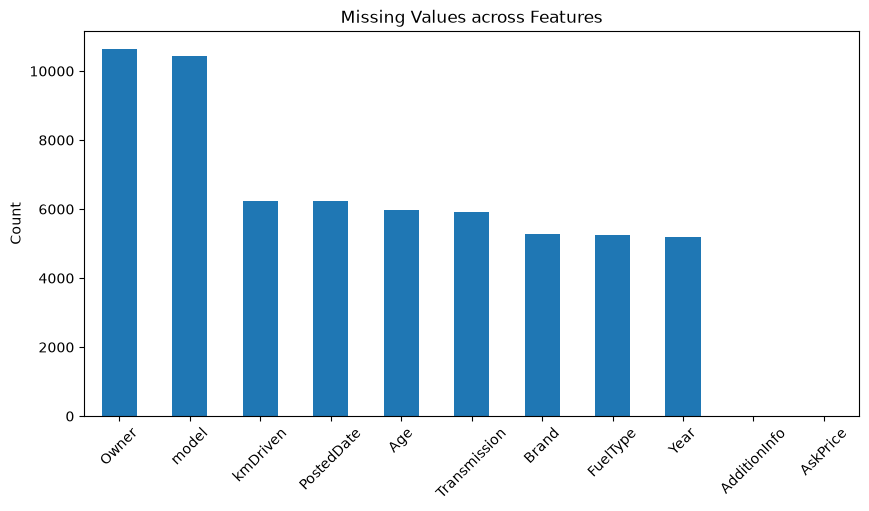

In [261]:
import matplotlib.pyplot as plt

missing = df.isnull().sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))

missing.plot(kind="bar")

plt.title("Missing Values across Features")

plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

In [262]:
missing_percent = (df.isnull().sum()/len(df)*100)\
                    .sort_values(ascending=False)

missing_percent

Owner           43.239064
model           42.445575
kmDriven        25.355036
PostedDate      25.310275
Age             24.313327
Transmission    24.097660
Brand           21.440488
FuelType        21.318413
Year            21.074262
AdditionInfo     0.000000
AskPrice         0.000000
dtype: float64

## Data Quality Observations ##

The initial quality assessment revealed that several features contain missing values.

The highest levels of missingness occur within categorical variables such as Owner and Model, while numerical features such as kmDriven also contain incomplete records.

These missing values cannot simply be removed without first evaluating their potential impact on the predictive model. Appropriate imputation strategies will therefore be considered during the preprocessing stage.

# Understanding the Dataset #

Before exploring relationships between variables, it is important to understand what each feature represents and how it may influence the asking price of a used vehicle.

In [263]:
data_dictionary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values,
    "Non-Null Count": df.notnull().sum().values,
    "Missing Values": df.isnull().sum().values,
    "Unique Values": df.nunique().values
})

data_dictionary

,Column,Data Type,Non-Null Count,Missing Values,Unique Values
0,Brand,str,19306,5269,41
1,model,str,14144,10431,403
2,Year,float64,19396,5179,36
3,Age,float64,18600,5975,33
4,kmDriven,str,18344,6231,2303
5,Transmission,str,18653,5922,2
6,Owner,str,13949,10626,2
7,FuelType,str,19336,5239,5
8,PostedDate,str,18355,6220,12
9,AdditionInfo,str,24575,0,10676


### Interpretation

The dataset consists of a mixture of numerical and categorical variables with varying levels of completeness.

While several variables contain substantial missing values, every feature remains potentially valuable for predicting vehicle prices. Rather than removing observations prematurely, missing values will be addressed during preprocessing using appropriate imputation techniques.

The dataset also contains duplicate observations and inconsistent data formats that require cleaning before exploratory analysis.

# Data Quality Assesment

A high-quality dataset is essential for developing accurate and reliable machine learning models. Therefore, this assessment focuses on identifying missing values, duplicate records, inconsistent data types, and other potential issues that could impact model performance.

## Transition to Data Cleaning

Following the initial assessment, several data quality issues were identified that could negatively affect model performance.

The next stage focuses on preparing the dataset by removing duplicate observations, correcting inconsistent data formats, and resolving invalid values before exploratory data analysis.

# Data Cleaning Preparation

In [264]:
df.dtypes

Brand               str
model               str
Year            float64
Age             float64
kmDriven            str
Transmission        str
Owner               str
FuelType            str
PostedDate          str
AdditionInfo        str
AskPrice            str
dtype: object

In [265]:
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 9587


In [266]:
duplicates = df[df.duplicated(keep=False)]

duplicates.head(10)

,Brand,model,Year,Age,kmDriven,Transmission,Owner,FuelType,PostedDate,AdditionInfo,AskPrice
0,NaN,NaN,2001.0,23.0,"98,000 km",NaN,NaN,Unknown,Nov-24,"Honda City v teck in mint condition, valid gen...","₹ 1,95,000"
1,Toyota,NaN,NaN,15.0,190000.0 km,Manual,NaN,Diesel,Jul-24,"Toyota Innova 2.5 G (Diesel) 7 Seater, 2009, D...","₹ 3,75,000"
2,Volkswagen,NaN,2010.0,NaN,NaN,Manual,first,NaN,Nov-24,"Volkswagen Vento 2010-2013 Diesel Breeze, 2010...","₹ 1,84,999"
3,NaN,Swift,2017.0,7.0,NaN,Manual,second,Unknown,NaN,Maruti Suzuki Swift 2017 Diesel Good Condition,"₹ 5,65,000"
4,Maruti Suzuki,NaN,2019.0,5.0,NaN,Automatic,NaN,Unknown,Nov-24,"Maruti Suzuki Baleno Alpha CVT, 2019, Petrol","₹ 6,85,000"
5,BMW,NaN,2014.0,NaN,"83,000 km",NaN,first,Unknown,Nov-24,"BMW X3 2.0 XDRIVE 20D, 2014, Diesel","₹ 13,50,000"
6,Unknown,NaN,NaN,10.0,"168,000 km",Manual,second,Diesel,Nov-24,"Toyota Innova 2.5 VX 8 Seater BS IV, 2014, Diesel","₹ 10,25,000"
7,BMW,NaN,2019.0,5.0,NaN,Automatic,NaN,Diesel,Nov-24,"BMW 5 Series 3.0 530D M Sport, 2019, Diesel","₹ 59,50,000"
8,Maruti Suzuki,NaN,9999.0,NaN,"33,759 km",Manual,NaN,Petrol,Nov-24,"Maruti Suzuki Dzire 1.2 VXI, 2020, Petrol","₹ 6,22,000"
9,Ford,Ecosport,9999.0,NaN,NaN,Manual,second,NaN,NaN,"Ford Ecosport 1.5 Ti VCT MT Titanium BE, 2017,...","₹ 6,49,000"


In [267]:
duplicate_percentage = (df.duplicated().sum() / len(df)) * 100

print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Percentage of duplicates: {duplicate_percentage:.2f}%")

Duplicate rows: 9587
Percentage of duplicates: 39.01%


In [268]:
df_no_duplicates = df.drop_duplicates()

print(f"Original rows: {len(df)}")
print(f"Rows after removing duplicates: {len(df_no_duplicates)}")
print(f"Rows removed: {len(df) - len(df_no_duplicates)}")

Original rows: 24575
Rows after removing duplicates: 14988
Rows removed: 9587


In [269]:
duplicates = df[df.duplicated(keep=False)]

duplicates.sort_values(by=list(df.columns)).head(20)

,Brand,model,Year,Age,kmDriven,Transmission,Owner,FuelType,PostedDate,AdditionInfo,AskPrice
8772,Ambassador,NaN,9999.0,21.0,1 km,NaN,second,NaN,Nov-24,Ambassador isuzu,"₹ 1,55,000"
18354,Ambassador,NaN,9999.0,21.0,1 km,NaN,second,NaN,Nov-24,Ambassador isuzu,"₹ 1,55,000"
3383,Audi,A3,2015.0,NaN,"42,000 km",NaN,NaN,Diesel,Nov-24,"Audi A3 2.0 35 TDI Attraction, 2015, Diesel","₹ 10,50,000"
12965,Audi,A3,2015.0,NaN,"42,000 km",NaN,NaN,Diesel,Nov-24,"Audi A3 2.0 35 TDI Attraction, 2015, Diesel","₹ 10,50,000"
2455,Audi,A3,2015.0,NaN,"42,000 km",NaN,NaN,NaN,NaN,"Audi A3 2.0 35 TDI Attraction, 2015, Diesel","₹ 10,50,000"
12037,Audi,A3,2015.0,NaN,"42,000 km",NaN,NaN,NaN,NaN,"Audi A3 2.0 35 TDI Attraction, 2015, Diesel","₹ 10,50,000"
3171,Audi,A3,9999.0,8.0,NaN,NaN,second,NaN,NaN,"Audi A3 35 TDI S Line, 2016, Diesel","₹ 9,49,000"
12753,Audi,A3,9999.0,8.0,NaN,NaN,second,NaN,NaN,"Audi A3 35 TDI S Line, 2016, Diesel","₹ 9,49,000"
23,Audi,A3,9999.0,9.0,"42,000 km",Automatic,NaN,NaN,Nov-24,"Audi A3 2.0 35 TDI Attraction, 2015, Diesel","₹ 10,50,000"
9605,Audi,A3,9999.0,9.0,"42,000 km",Automatic,NaN,NaN,Nov-24,"Audi A3 2.0 35 TDI Attraction, 2015, Diesel","₹ 10,50,000"


## Duplicate Records

A total of 9,587 duplicate records (39.01%) were identified in the dataset.

Inspection confirmed that these records were exact duplicates rather than distinct vehicles with similar attributes. To prevent duplicate observations from biasing the machine learning model, duplicate rows will be removed while retaining the first occurrence of each record.

In [270]:
df = df.drop_duplicates()

print(f"New dataset shape: {df.shape}")

New dataset shape: (14988, 11)


In [271]:
df["AskPrice"] = (
    df["AskPrice"]
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
    .astype(int)
)

df["AskPrice"].head()

0    195000
1    375000
2    184999
3    565000
4    685000
Name: AskPrice, dtype: int64

In [272]:
df["kmDriven"] = (
    df["kmDriven"]
    .str.replace(" km", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.replace(".0", "", regex=False)
)

df["kmDriven"] = pd.to_numeric(df["kmDriven"], errors="coerce")

df["kmDriven"].head()

0     98000.0
1    190000.0
2         NaN
3         NaN
4         NaN
Name: kmDriven, dtype: float64

In [273]:
df["kmDriven"].dtype

dtype('float64')

## Correcting Invalid Year Values

Inspection of the **Year** feature revealed that a substantial number of records contained the value **9999**, which is not a valid vehicle manufacturing year. These values would distort statistical analysis and negatively affect the machine learning model if left uncorrected.

To preserve as much information as possible, the invalid values were handled using the following approach:

- Where the vehicle's **Age** was available, the manufacturing year was estimated using:
  
  **Year = 2024 − Age**

- Where both **Year** and **Age** were unavailable, the invalid value was replaced with a missing value (`NaN`) so that it could be handled appropriately during preprocessing.

This approach improves data quality while minimizing unnecessary information loss.

In [274]:
df["Year"].describe()

count    12391.000000
mean      3666.820192
std       3233.002118
min       1900.000000
25%       2015.000000
50%       2018.000000
75%       2022.000000
max       9999.000000
Name: Year, dtype: float64

In [275]:
df["Year"].value_counts().sort_index().tail(10)

Year
2016.0     936
2017.0    1028
2018.0    1077
2019.0     833
2020.0     544
2021.0     562
2022.0     524
2023.0     342
2024.0     191
9999.0    2562
Name: count, dtype: int64

In [276]:
df.loc[
    (df["Year"] == 9999) & (df["Age"].notna()),
    "Year"
] = 2024 - df.loc[
    (df["Year"] == 9999) & (df["Age"].notna()),
    "Age"
]

In [277]:
(df["Year"] == 9999).sum()

np.int64(703)

In [278]:
df.loc[df["Year"] == 9999, "Year"] = np.nan

In [279]:
df["Year"].describe()

count    11688.000000
mean      2016.298169
std          4.413277
min       1900.000000
25%       2014.000000
50%       2017.000000
75%       2019.000000
max       2024.000000
Name: Year, dtype: float64

In [280]:
df.to_csv("../Data/processed/used_cars_cleaned.csv", index=False)

print(" Cleaned dataset saved successfully!")

 Cleaned dataset saved successfully!


# Notebook 1 Conclusion

I have identified several issues that required correction before modelling.

### Key Findings
- Original observations: 24,575
- Duplicate records removed: 9,587
- Final observations: 14,988
- AskPrice converted to numeric.
- kmDriven converted to numeric.
- Invalid Year values corrected using Age where possible.
- Remaining invalid Year values converted to missing values.
- Cleaned dataset exported for exploratory data analysis.

The data quality assessment and initial cleaning process successfully prepared the dataset for the next stage of the CRISP-DM methodology.

Major quality issues: including duplicate records, inconsistent numerical formats, and invalid manufacturing years—were identified and addressed while preserving as much useful information as possible.

The cleaned dataset has been exported and is now ready for exploratory data analysis, where feature distributions, relationships, and potential predictors of vehicle prices will be investigated.

## Notebook 2
### Purpose

The purpose of this notebook is to explore the cleaned used car dataset and identify the key factors that influence vehicle asking prices.

The insights gained from this analysis will guide feature engineering, model development, and business recommendations.

## CRISP-DM Phase

This notebook focuses on the **Data Understanding** phase of the CRISP-DM methodology.

The objective is to explore the cleaned dataset, identify relationships between variables, detect patterns and anomalies, and generate business insights that will guide feature engineering and machine learning model development.

In [281]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)

print("Libraries imported successfully!")

Libraries imported successfully!


In [282]:
df = pd.read_csv("../Data/processed/used_cars_cleaned.csv")

print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,Brand,model,Year,Age,kmDriven,Transmission,Owner,FuelType,PostedDate,AdditionInfo,AskPrice
0,NaN,NaN,2001.0,23.0,98000.0,NaN,NaN,Unknown,Nov-24,"Honda City v teck in mint condition, valid gen...",195000
1,Toyota,NaN,NaN,15.0,190000.0,Manual,NaN,Diesel,Jul-24,"Toyota Innova 2.5 G (Diesel) 7 Seater, 2009, D...",375000
2,Volkswagen,NaN,2010.0,NaN,NaN,Manual,first,NaN,Nov-24,"Volkswagen Vento 2010-2013 Diesel Breeze, 2010...",184999
3,NaN,Swift,2017.0,7.0,NaN,Manual,second,Unknown,NaN,Maruti Suzuki Swift 2017 Diesel Good Condition,565000
4,Maruti Suzuki,NaN,2019.0,5.0,NaN,Automatic,NaN,Unknown,Nov-24,"Maruti Suzuki Baleno Alpha CVT, 2019, Petrol",685000


In [283]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

df.info()

Rows: 14,988
Columns: 11
<class 'pandas.DataFrame'>
RangeIndex: 14988 entries, 0 to 14987
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         12347 non-null  str    
 1   model         9755 non-null   str    
 2   Year          11688 non-null  float64
 3   Age           11995 non-null  float64
 4   kmDriven      11840 non-null  float64
 5   Transmission  12018 non-null  str    
 6   Owner         9659 non-null   str    
 7   FuelType      12359 non-null  str    
 8   PostedDate    11867 non-null  str    
 9   AdditionInfo  14988 non-null  str    
 10  AskPrice      14988 non-null  int64  
dtypes: float64(3), int64(1), str(7)
memory usage: 2.3 MB


## Question 1

### How are used car asking prices distributed?

Understanding the distribution of asking prices helps identify the typical price range of used vehicles, detect skewness, and identify potential outliers that may influence machine learning model performance.

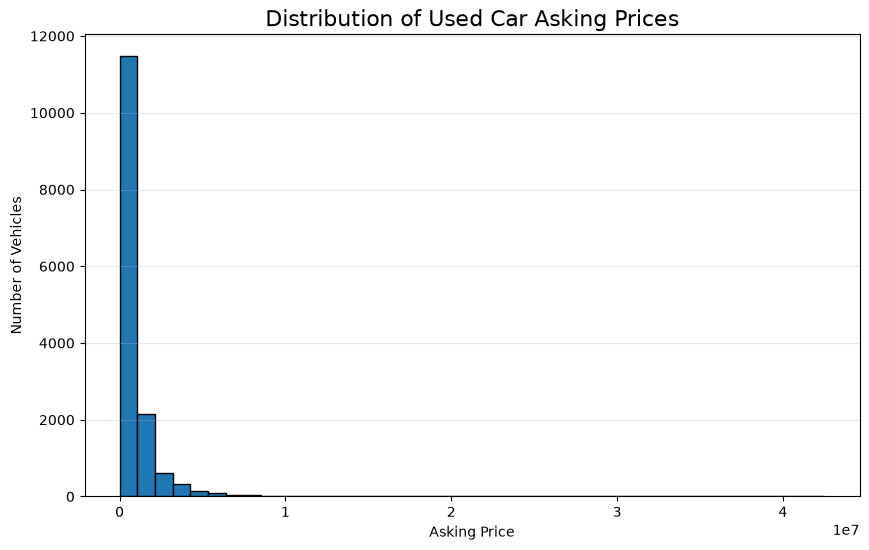

In [284]:
plt.figure(figsize=(10,6))

plt.hist(
    df["AskPrice"],
    bins=40,
    edgecolor="black"
)

plt.title("Distribution of Used Car Asking Prices", fontsize=16)
plt.xlabel("Asking Price")
plt.ylabel("Number of Vehicles")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [285]:
df["AskPrice"].describe()

count    1.498800e+04
mean     9.968848e+05
std      1.586835e+06
min      1.500000e+04
25%      3.490000e+05
50%      5.700000e+05
75%      1.025000e+06
max      4.250000e+07
Name: AskPrice, dtype: float64

In [286]:
print(f"Skewness: {df['AskPrice'].skew():.2f}")

Skewness: 8.12


### Interpretation

The distribution of used car asking prices is highly positively (right) skewed. Most vehicles are listed within the lower and middle price ranges, while only a small proportion of luxury vehicles have exceptionally high asking prices.

The summary statistics support this observation. The mean asking price (₹996,885) is substantially higher than the median (₹570,000), and the skewness coefficient of **8.12** confirms a highly right-skewed distribution. This indicates the presence of extreme high-value vehicles that influence the overall distribution.

### Insight

The used car market represented in this dataset is dominated by affordable and mid-range vehicles, while luxury vehicles make up only a small proportion of listings.

The strong positive skew (8.12) suggests that extreme vehicle prices could disproportionately influence predictive models. During the modelling phase, techniques such as target transformation and robust regression models will be considered to improve prediction performance.

## Question 2

### Which vehicle brands have the highest median asking prices?

Different vehicle manufacturers target different market segments. Comparing the median asking price across brands helps identify premium brands and understand how brand reputation influences resale value.

In [287]:
brand_price = (
    df.groupby("Brand")["AskPrice"]
      .median()
      .sort_values(ascending=False)
      .head(15)
)

brand_price

Brand
Rolls-Royce      42500000.0
Lamborghini      39000000.0
Bentley          18500000.0
Hummer            9800000.0
Maserati          8000000.0
Porsche           8000000.0
Toyota Land       7100000.0
Lexus             4650000.0
Land Rover        3924999.5
Mini              3300000.0
Jaguar            2440000.0
Mercedes-Benz     2200000.0
BMW               2099999.0
Citroen           1950000.0
Volvo             1775000.0
Name: AskPrice, dtype: float64

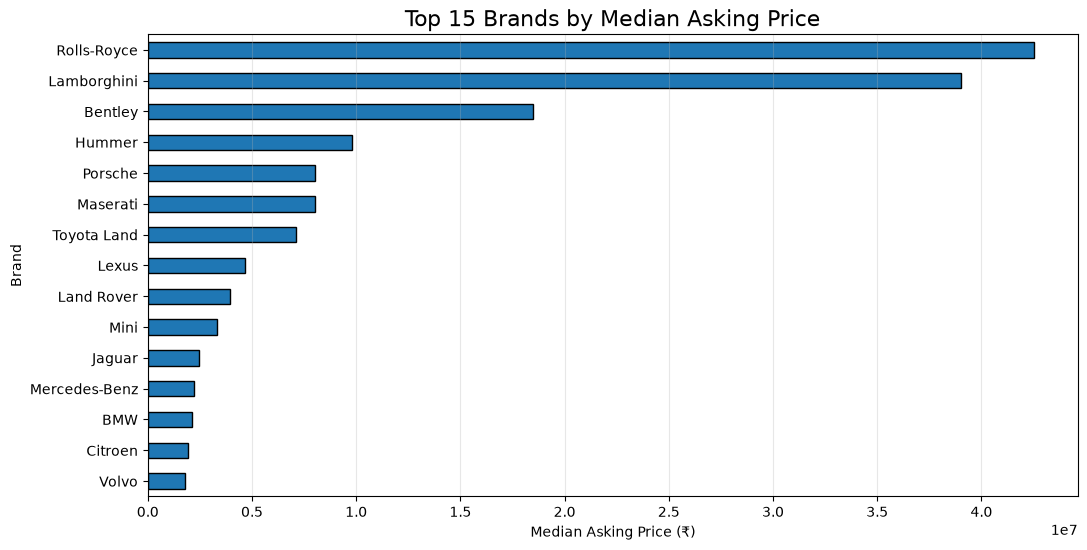

In [288]:
plt.figure(figsize=(12,6))

brand_price.sort_values().plot(
    kind="barh",
    edgecolor="black"
)

plt.title("Top 15 Brands by Median Asking Price", fontsize=16)
plt.xlabel("Median Asking Price (₹)")
plt.ylabel("Brand")

plt.grid(axis="x", alpha=0.3)

plt.show()

In [289]:
brand_summary = (
    df.groupby("Brand")
      .agg(
          Number_of_Cars=("AskPrice", "count"),
          Median_Price=("AskPrice", "median")
      )
      .sort_values(by="Median_Price", ascending=False)
)

brand_summary.head(15)

,Number_of_Cars,Median_Price
Brand,,
Rolls-Royce,1,42500000.0
Lamborghini,1,39000000.0
Bentley,1,18500000.0
Hummer,1,9800000.0
Maserati,1,8000000.0
Porsche,19,8000000.0
Toyota Land,4,7100000.0
Lexus,19,4650000.0
Land Rover,56,3924999.5


### Interpretation

Luxury brands such as Rolls-Royce, Lamborghini, Bentley and Hummer recorded the highest median asking prices. However, several of these brands are represented by only one vehicle listing, meaning their median prices may not be representative of the broader market.

### Insight

Brand reputation is one of the strongest drivers of used vehicle prices. Premium manufacturers consistently command higher asking prices than mainstream brands.

However, business decisions should not rely solely on brands represented by very few listings. Brands such as Mercedes-Benz, BMW and Land Rover provide more reliable insights because they are supported by a much larger number of observations, making their pricing trends more representative of the market.

## Question 3

### How does vehicle age influence asking price?

Vehicle age is one of the most important factors affecting depreciation. Understanding this relationship provides valuable insight into how resale values change over time and helps determine whether age should be a key predictor in the machine learning model.

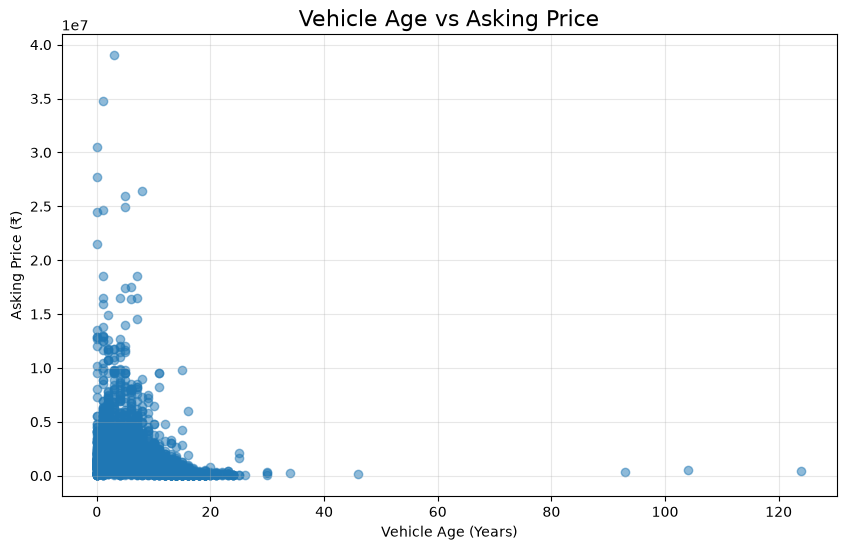

In [290]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["Age"],
    df["AskPrice"],
    alpha=0.5
)

plt.title("Vehicle Age vs Asking Price", fontsize=16)
plt.xlabel("Vehicle Age (Years)")
plt.ylabel("Asking Price (₹)")

plt.grid(alpha=0.3)

plt.show()

In [291]:
correlation = df[["Age", "AskPrice"]].corr()

correlation

,Age,AskPrice
Age,1.000000,-0.281751
AskPrice,-0.281751,1.000000


In [292]:
print(f"Correlation: {df['Age'].corr(df['AskPrice']):.2f}")

Correlation: -0.28


Interpretation

The scatter plot shows that newer vehicles generally have higher asking prices, while older vehicles tend to be listed at lower prices. The correlation coefficient of -0.282 confirms a weak to moderate negative relationship between vehicle age and asking price. Although price generally decreases as vehicles age, the wide spread of points indicates that other factors such as brand, mileage, fuel type, and transmission also influence vehicle prices.

## Question 4
### Does vehicle mileage influence asking price?

Mileage is commonly associated with vehicle wear and depreciation. Analysing the relationship between kilometers driven and asking price helps determine whether higher mileage consistently reduces resale value and whether mileage should be considered an important predictor in the machine learning model.

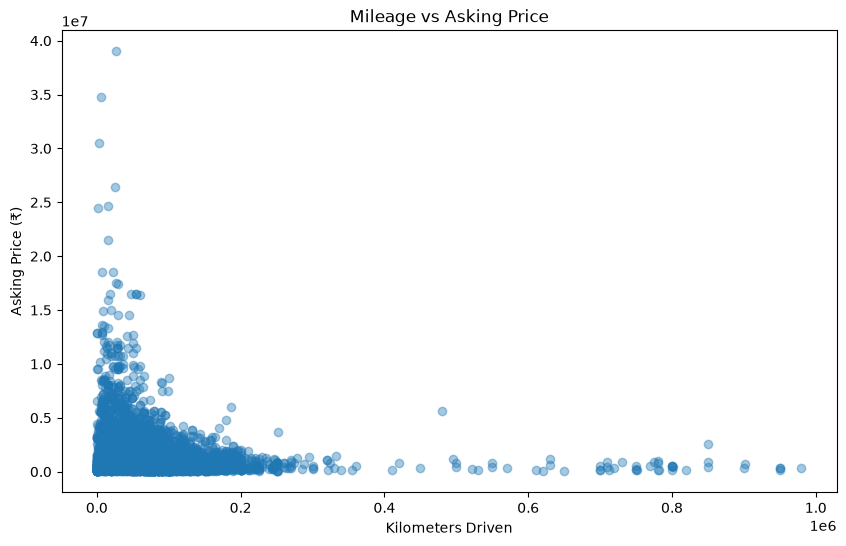

In [293]:
plt.figure(figsize=(10,6))

plt.scatter(df["kmDriven"], df["AskPrice"], alpha=0.4)

plt.title("Mileage vs Asking Price")

plt.xlabel("Kilometers Driven")

plt.ylabel("Asking Price (₹)")

plt.show()

In [294]:
df[["kmDriven", "AskPrice"]].corr()

,kmDriven,AskPrice
kmDriven,1.000000,-0.141863
AskPrice,-0.141863,1.000000


Interpretation

The scatter plot indicates a slight downward trend between mileage and asking price. Vehicles with lower mileage generally command higher asking prices, while cars with higher mileage tend to be less expensive. The correlation coefficient of -0.142 indicates a weak negative relationship, suggesting that mileage influences vehicle prices but is not the only determining factor. Other features such as vehicle age, brand, fuel type, and transmission are also likely to contribute significantly to pricing.

## Question 5

### Do transmission types influence used car asking prices?

Vehicle transmission type is often associated with consumer preferences, driving experience, and vehicle segment. Comparing asking prices across transmission types helps determine whether automatic vehicles command higher resale values than manual vehicles.

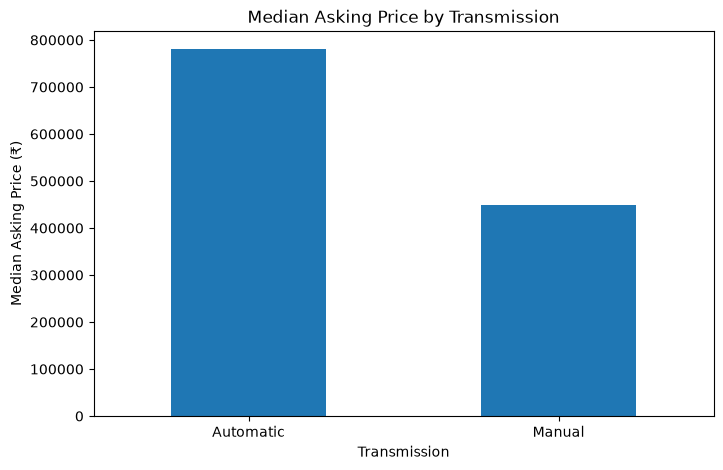

Transmission
Automatic    780000.0
Manual       450000.0
Name: AskPrice, dtype: float64

In [295]:
median_price = (
    df.groupby("Transmission")["AskPrice"]
      .median()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

median_price.plot(kind="bar")

plt.title("Median Asking Price by Transmission")

plt.xlabel("Transmission")

plt.ylabel("Median Asking Price (₹)")

plt.xticks(rotation=0)

plt.show()

median_price

Interpretation

The results show that vehicles with automatic transmission have a substantially higher median asking price (₹780,000) than vehicles with manual transmission (₹450,000). This suggests that automatic vehicles are generally positioned in the higher-priced segment of the used car market. The difference may reflect stronger demand for automatic vehicles, their prevalence among newer models, and their association with premium vehicle brands.

## Question 6

### How do asking price distributions vary across the most common vehicle brands?

While median prices provide a useful summary, they do not show the spread or variability of prices within each brand.

A boxplot allows us to compare the distribution, median, interquartile range, and potential outliers across the most frequently listed vehicle brands. This provides a more comprehensive understanding of how brand influences resale value.

<Figure size 1400x700 with 0 Axes>

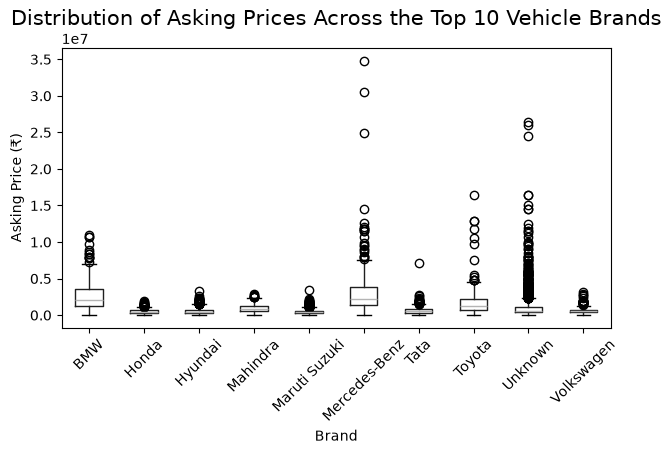

In [296]:
# Top 10 brands by number of listings

top_brands = (
    df["Brand"]
    .value_counts()
    .head(10)
    .index
)

brand_df = df[df["Brand"].isin(top_brands)]

plt.figure(figsize=(14,7))

brand_df.boxplot(
    column="AskPrice",
    by="Brand",
    rot=45,
    grid=False
)

plt.title("Distribution of Asking Prices Across the Top 10 Vehicle Brands", fontsize=15)

plt.suptitle("")   # removes automatic subtitle

plt.xlabel("Brand")

plt.ylabel("Asking Price (₹)")

plt.tight_layout()

plt.show()

### Interpretation

The boxplot reveals substantial variation in asking prices across the most frequently listed vehicle brands.

Premium brands such as **Mercedes-Benz** and **BMW** exhibit noticeably higher median prices together with wider price ranges, reflecting the diversity of luxury vehicle models within these brands.

In contrast, mainstream manufacturers such as **Maruti Suzuki**, **Hyundai**, and **Honda** display lower median asking prices and comparatively narrower distributions, indicating greater pricing consistency.

Several brands also contain high-value outliers, suggesting that premium trims and newer vehicle models can command considerably higher prices than the typical listing within the same brand.

### Business Insight

The distribution of asking prices varies considerably across vehicle brands, confirming that brand is one of the strongest determinants of resale value.

The presence of wide price ranges within premium brands indicates that vehicle characteristics such as model, age, mileage, and trim level also contribute significantly to pricing.

These findings reinforce the importance of incorporating brand alongside other vehicle attributes when developing predictive machine learning models.

## Question 7

### Does fuel type influence asking price?

Different fuel types appeal to different segments of the market and may influence resale values. Comparing asking prices across fuel types helps identify whether certain fuel categories consistently command higher prices.

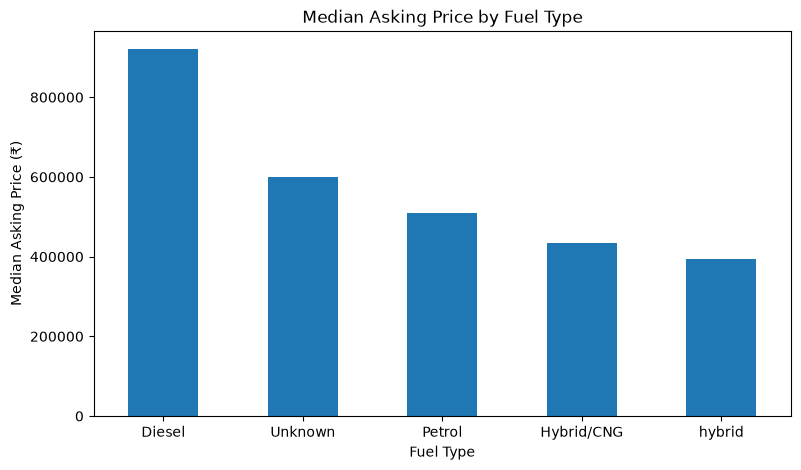

FuelType
Diesel        920000.0
Unknown       599999.0
Petrol        510000.0
Hybrid/CNG    435000.0
hybrid        395000.0
Name: AskPrice, dtype: float64

In [297]:
fuel_price = (
    df.groupby("FuelType")["AskPrice"]
      .median()
      .sort_values(ascending=False)
)

plt.figure(figsize=(9,5))

fuel_price.plot(kind="bar")

plt.title("Median Asking Price by Fuel Type")

plt.xlabel("Fuel Type")

plt.ylabel("Median Asking Price (₹)")

plt.xticks(rotation=0)

plt.show()

fuel_price

The presence of separate "Hybrid/CNG" and "hybrid" categories suggests minor inconsistencies in the source data, which could be addressed during future data quality improvements.

## Interpretation.

Diesel vehicles have the highest median asking price (₹920,000), followed by vehicles with an unknown fuel type (₹600,000) and petrol vehicles (₹510,000). Hybrid/CNG and hybrid vehicles have the lowest median asking prices in this dataset. The results suggest that fuel type influences vehicle pricing, although the "Unknown" category should be interpreted cautiously because it represents missing or incomplete information rather than a true fuel type.

## Question 8

### What relationships exist among the numerical variables?

Understanding correlations between numerical variables provides insight into how vehicle characteristics interact and helps identify features that may be important predictors of asking price.

In [298]:
correlation = df[["Year", "Age", "kmDriven", "AskPrice"]].corr()

correlation

,Year,Age,kmDriven,AskPrice
Year,1.000000,-1.000000,-0.270199,0.277792
Age,-1.000000,1.000000,0.260750,-0.281751
kmDriven,-0.270199,0.260750,1.000000,-0.141863
AskPrice,0.277792,-0.281751,-0.141863,1.000000


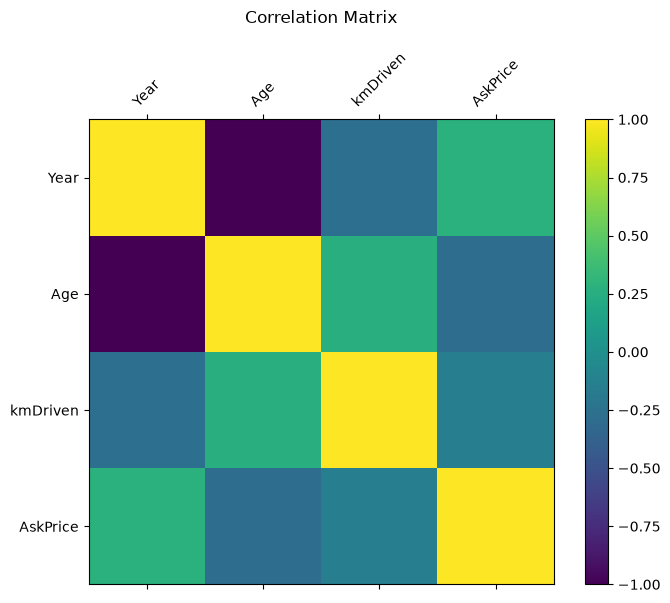

In [299]:
plt.figure(figsize=(8,6))

plt.matshow(correlation, fignum=1)

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix", pad=20)

plt.show()

## Interpretation

The correlation matrix reveals several important relationships between the variables. Vehicle Year has a weak positive correlation with asking price (0.278), indicating that newer vehicles generally have higher prices. Age has a weak negative correlation with asking price (-0.282), suggesting that older vehicles tend to sell for less. Kilometers Driven also shows a weak negative correlation with asking price (-0.142), meaning that vehicles with higher mileage are generally less expensive. As expected, Year and Age have an almost perfect negative correlation (-1.000) because vehicle age is directly derived from the manufacturing year.

## Business Insight

The exploratory analysis indicates that vehicle prices are influenced by multiple interacting factors rather than a single characteristic.

Brand, vehicle age, manufacturing year, transmission type, fuel type, and mileage all demonstrate measurable relationships with asking price. These findings suggest that combining these variables within a machine learning model is likely to produce more accurate price predictions than relying on any individual feature alone.

These observations will guide the feature engineering process presented in the next notebook.

## Overall Findings

This exploratory data analysis identified several factors associated with used vehicle asking prices.

Key findings include:

- Asking prices are highly right-skewed.
- Premium brands consistently command higher resale values.
- Vehicle age is negatively associated with asking price.
- Higher mileage generally corresponds to lower asking prices.
- Automatic vehicles have higher median asking prices.
- Diesel vehicles exhibit the highest median asking price in this dataset.
- Vehicle pricing is influenced by multiple interacting characteristics rather than a single factor.

## Conclusion

The exploratory data analysis successfully identified several vehicle characteristics associated with used car asking prices.

While no single feature fully explains price variation, the combined influence of brand, age, manufacturing year, mileage, transmission, and fuel type provides valuable insight into the factors driving vehicle values.

These findings establish a strong analytical foundation for the next phase of the project, where feature engineering and predictive machine learning models will be developed.

## Notebook 3

## Purpose

The purpose of this notebook is to prepare the cleaned dataset for machine learning.

This includes handling missing values, engineering useful features, encoding categorical variables, scaling numerical features where appropriate, and splitting the data into training and testing datasets. The resulting dataset will be used to train and evaluate regression models that predict used car asking prices.

## CRISP-DM Phase

This notebook focuses on the **Data Preparation** phase of the CRISP-DM methodology.

The objective is to transform the cleaned dataset into a machine learning-ready format by handling missing values, engineering features, encoding categorical variables, and creating separate training and testing datasets for model development.

In [300]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

In [301]:
df = pd.read_csv("../Data/processed/used_cars_cleaned.csv")

print(df.shape)

df.head()

(14988, 11)


,Brand,model,Year,Age,kmDriven,Transmission,Owner,FuelType,PostedDate,AdditionInfo,AskPrice
0,NaN,NaN,2001.0,23.0,98000.0,NaN,NaN,Unknown,Nov-24,"Honda City v teck in mint condition, valid gen...",195000
1,Toyota,NaN,NaN,15.0,190000.0,Manual,NaN,Diesel,Jul-24,"Toyota Innova 2.5 G (Diesel) 7 Seater, 2009, D...",375000
2,Volkswagen,NaN,2010.0,NaN,NaN,Manual,first,NaN,Nov-24,"Volkswagen Vento 2010-2013 Diesel Breeze, 2010...",184999
3,NaN,Swift,2017.0,7.0,NaN,Manual,second,Unknown,NaN,Maruti Suzuki Swift 2017 Diesel Good Condition,565000
4,Maruti Suzuki,NaN,2019.0,5.0,NaN,Automatic,NaN,Unknown,Nov-24,"Maruti Suzuki Baleno Alpha CVT, 2019, Petrol",685000


## Question 1

### Which features contain missing values that require preprocessing?

Missing values can negatively affect machine learning algorithms by reducing predictive performance or preventing models from training successfully. Identifying incomplete variables allows appropriate preprocessing strategies to be selected before model development.


In [302]:
df.isnull().sum().sort_values(ascending=False)

Owner           5329
model           5233
Year            3300
kmDriven        3148
PostedDate      3121
Age             2993
Transmission    2970
Brand           2641
FuelType        2629
AdditionInfo       0
AskPrice           0
dtype: int64

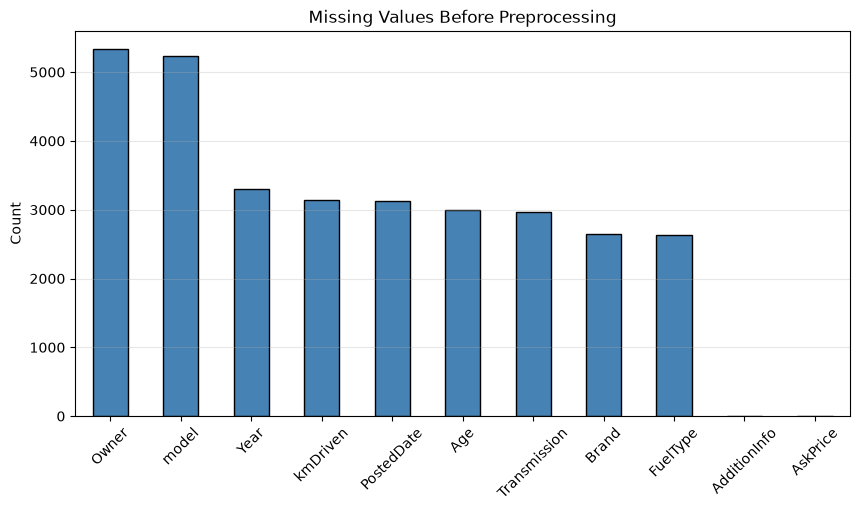

In [303]:
missing = df.isnull().sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))

missing.plot(kind="bar", color="steelblue", edgecolor="black")

plt.title("Missing Values Before Preprocessing")

plt.ylabel("Count")

plt.xticks(rotation=45)

plt.grid(axis="y", alpha=0.3)

plt.show()

## Question 2

### How should missing values be handled?

Missing values must be addressed before training machine learning models because many algorithms cannot process incomplete observations. Appropriate imputation techniques help preserve valuable information while minimizing the impact of missing data on model performance.




In [304]:
df["Brand"] = df["Brand"].fillna("Unknown")
df["model"] = df["model"].fillna("Unknown")
df["Owner"] = df["Owner"].fillna("Unknown")
df["FuelType"] = df["FuelType"].fillna("Unknown")
df["Transmission"] = df["Transmission"].fillna("Unknown")
df["PostedDate"] = df["PostedDate"].fillna("Unknown")

In [305]:
df["Year"] = df["Year"].fillna(df["Year"].median())
df["Age"] = df["Age"].fillna(df["Age"].median())
df["kmDriven"] = df["kmDriven"].fillna(df["kmDriven"].median())

In [306]:
df.isnull().sum()

Brand           0
model           0
Year            0
Age             0
kmDriven        0
Transmission    0
Owner           0
FuelType        0
PostedDate      0
AdditionInfo    0
AskPrice        0
dtype: int64

## Interpretation ##

Missing values were successfully handled using appropriate strategies based on each variable type. Numerical variables (Year, Age and kmDriven) were imputed using the median to reduce the influence of outliers, while categorical variables were filled with "Unknown" to preserve missing information without removing observations. After preprocessing, no missing values remained in the dataset.

## Question 3

### Which features should be retained for machine learning?

Not every variable contributes equally to predictive performance. Removing irrelevant or unstructured features simplifies the dataset and reduces unnecessary model complexity.


In [307]:
df = df.drop(columns=["AdditionInfo"])

In [308]:
X = df.drop("AskPrice", axis=1)

y = df["AskPrice"]

# Feature Engineering #

Machine learning algorithms require numerical input features. Therefore, categorical variables such as Brand, FuelType, Transmission, Owner, Model and PostedDate were converted into numerical indicators using One-Hot Encoding.

The AdditionInfo column was removed because it contains unstructured text that will not be used in the baseline regression models.

## Question 4

### How can categorical variables be converted into numerical features?

Most machine learning algorithms require numerical input variables. One-Hot Encoding transforms categorical variables into binary indicator variables while preserving the information contained within each category.


In [309]:
X = pd.get_dummies(
    X,
    drop_first=True
)

X.head()

,Year,Age,kmDriven,Brand_Audi,Brand_BMW,Brand_Bajaj,Brand_Bentley,Brand_Chevrolet,Brand_Citroen,Brand_Datsun,Brand_Fiat,Brand_Force,Brand_Ford,Brand_Honda,Brand_Hummer,Brand_Hyundai,Brand_Isuzu,Brand_Jaguar,Brand_Jeep,Brand_Kia,Brand_Lamborghini,Brand_Land Rover,Brand_Lexus,Brand_MG,Brand_Mahindra,Brand_Maruti Suzuki,Brand_Maserati,Brand_Mercedes-Benz,Brand_Mini,Brand_Mitsubishi,Brand_Nissan,Brand_Opel,Brand_Porsche,Brand_Renault,Brand_Rolls-Royce,Brand_Skoda,Brand_Ssangyong,Brand_Tata,Brand_Toyota,Brand_Toyota Land,Brand_Unknown,Brand_Volkswagen,Brand_Volvo,model_1000,model_2 Series,model_2.8 Legender 4X2,model_2.9 Sportback,model_3 DOOR,model_3 Series,model_3 Series GT,model_3 Series Gran Limousine,model_5 Series,model_5 Series Gt,model_6 Series,model_6 Series GT,model_7 Series,model_718,model_718 CAYMAN,model_800,model_A Class,model_A-Class Limousine,model_A-Star,model_A3,model_A3 Cabriolet,model_A4,model_A5,model_A6,model_A8,model_A8 L,model_AMG GLE Coupe,model_ASTOR,model_Accent,model_Accent Hatchback,model_Accord,model_Alcazar,model_Alto,model_Alto 800,model_Alto K10,model_Alto-800,model_Alto-K10,model_Altroz,model_Alturas G4,model_Amaze,model_Ambassador,model_Ameo,model_Aria,model_Aspire,model_Aura,model_B Class,model_BRV,model_Baleno,model_Baleno-RS,model_Beat,model_Beetle,model_Bolero,model_Bolero Neo,model_Bolero Neo Plus,model_Bolero Power Plus,model_Bolt,model_Boxster,model_Brezza,model_Brio,model_C Class,model_C-Class,model_C5 Aircross,model_CERATO,model_CLA,model_CLS-Class,model_CR-V,model_CRV,model_Camry,model_Captiva,model_Captur,model_Carens,model_Carnival,model_Cayenne,model_Cayenne Coupe,model_Cayman,model_Celerio,model_Celerio X,model_Celerio-X,model_Ciaz,model_City,model_City Hybrid eHEV,model_City ZX,model_Civic,model_Compass,model_Cooper,model_Cooper 3 DOOR,model_Cooper 5 DOOR,model_Cooper Clubman,model_Cooper Convertible,model_Cooper Countryman,model_Cooper S,model_Corolla,model_Corolla Altis,model_Corsa,model_Countryman,model_Creta,model_Creta Facelift,model_CrossPolo,model_Cruiser,model_Cruiser Prado,model_Cruze,model_D-Max V-Cross,model_Defender,model_Discovery,model_Discovery Sport,model_Duster,model_Dzire,model_E-Class,model_EON,model_ES,model_Ecosport,model_Eeco,model_Elantra,model_Elevate,model_Elite i20,model_Endeavour,model_Enjoy,model_Eon,model_Ertiga,model_Escort,model_Esteem,model_Estilo,model_Estima,model_Etios,model_Etios Cross,model_Etios Liva,model_Exter,model_F-Pace,model_Fabia,model_Fiesta,model_Fiesta Classic,model_Figo,model_Figo Aspire,model_Five-door Thar,model_Fluence,model_Fluidic Verna,model_Fortuner,model_Free Style,model_Freelander 2,model_Fronx,model_Fronx,model_G,model_G Class,model_G-Class,model_GL-Class,model_GLA,model_GLA Class,model_GLC,model_GLC Class,model_GLE,model_GLE COUPE,model_GLE Class,model_GLS,model_GO,model_GO Plus,model_GTI,model_Getz,model_Getz Prime,model_Glanza,model_Gloster,model_Grand Punto,model_Grand Vitara,model_Grand i10,model_Grand i10 Nios,model_Grand i10 Prime,model_Grande Punto,model_Gypsy,model_H2,model_H5x,model_Harrier,model_Harrier EV,model_Hector,model_Hector Plus,model_Hexa,model_Hi-Lande Isuzu Hi-Lander,model_Ignis,model_Ikon,model_Imperio,model_Indica,model_Indica Ev2,model_Indica V2,model_Indica Vista,model_Indigo Cs,model_Indigo Ecs,model_Indigo Marina,model_Innova,model_Innova Crysta,model_Innova Hycross,model_Jazz,model_Jeep,model_Jetta,model_Jimny,model_KUV 100,model_KUV100 NXT,model_KWID,model_Karoq,model_Kicks,model_Kiger,model_Kodiaq,model_Kushaq,model_LS,model_Land Cruiser,model_Land Cruiser Prado,model_Laura,model_Linea,model_Lodgy,model_Logan,model_M-Class,model_M2,model_M340i,model_MICRA PRIMO,model_MU-X,model_MUX,model_Macan,model_Magnite,model_Manza,model_Marazzo,model_Marshal,model_Maxx,model_Meridian,model_Micra,model_Micra Active,model_Mobilio,model_Motors FM Gurkha,model_Motors FM Trax Cruiser,model_Mustang,model_NX,model_Nano,model_Nano Genx,model_New Accord,model_New Elantra,model_New Santro,model_New Verna,model_New i

In [310]:
print(X.shape)

X.head()

(14988, 466)


,Year,Age,kmDriven,Brand_Audi,Brand_BMW,Brand_Bajaj,Brand_Bentley,Brand_Chevrolet,Brand_Citroen,Brand_Datsun,Brand_Fiat,Brand_Force,Brand_Ford,Brand_Honda,Brand_Hummer,Brand_Hyundai,Brand_Isuzu,Brand_Jaguar,Brand_Jeep,Brand_Kia,Brand_Lamborghini,Brand_Land Rover,Brand_Lexus,Brand_MG,Brand_Mahindra,Brand_Maruti Suzuki,Brand_Maserati,Brand_Mercedes-Benz,Brand_Mini,Brand_Mitsubishi,Brand_Nissan,Brand_Opel,Brand_Porsche,Brand_Renault,Brand_Rolls-Royce,Brand_Skoda,Brand_Ssangyong,Brand_Tata,Brand_Toyota,Brand_Toyota Land,Brand_Unknown,Brand_Volkswagen,Brand_Volvo,model_1000,model_2 Series,model_2.8 Legender 4X2,model_2.9 Sportback,model_3 DOOR,model_3 Series,model_3 Series GT,model_3 Series Gran Limousine,model_5 Series,model_5 Series Gt,model_6 Series,model_6 Series GT,model_7 Series,model_718,model_718 CAYMAN,model_800,model_A Class,model_A-Class Limousine,model_A-Star,model_A3,model_A3 Cabriolet,model_A4,model_A5,model_A6,model_A8,model_A8 L,model_AMG GLE Coupe,model_ASTOR,model_Accent,model_Accent Hatchback,model_Accord,model_Alcazar,model_Alto,model_Alto 800,model_Alto K10,model_Alto-800,model_Alto-K10,model_Altroz,model_Alturas G4,model_Amaze,model_Ambassador,model_Ameo,model_Aria,model_Aspire,model_Aura,model_B Class,model_BRV,model_Baleno,model_Baleno-RS,model_Beat,model_Beetle,model_Bolero,model_Bolero Neo,model_Bolero Neo Plus,model_Bolero Power Plus,model_Bolt,model_Boxster,model_Brezza,model_Brio,model_C Class,model_C-Class,model_C5 Aircross,model_CERATO,model_CLA,model_CLS-Class,model_CR-V,model_CRV,model_Camry,model_Captiva,model_Captur,model_Carens,model_Carnival,model_Cayenne,model_Cayenne Coupe,model_Cayman,model_Celerio,model_Celerio X,model_Celerio-X,model_Ciaz,model_City,model_City Hybrid eHEV,model_City ZX,model_Civic,model_Compass,model_Cooper,model_Cooper 3 DOOR,model_Cooper 5 DOOR,model_Cooper Clubman,model_Cooper Convertible,model_Cooper Countryman,model_Cooper S,model_Corolla,model_Corolla Altis,model_Corsa,model_Countryman,model_Creta,model_Creta Facelift,model_CrossPolo,model_Cruiser,model_Cruiser Prado,model_Cruze,model_D-Max V-Cross,model_Defender,model_Discovery,model_Discovery Sport,model_Duster,model_Dzire,model_E-Class,model_EON,model_ES,model_Ecosport,model_Eeco,model_Elantra,model_Elevate,model_Elite i20,model_Endeavour,model_Enjoy,model_Eon,model_Ertiga,model_Escort,model_Esteem,model_Estilo,model_Estima,model_Etios,model_Etios Cross,model_Etios Liva,model_Exter,model_F-Pace,model_Fabia,model_Fiesta,model_Fiesta Classic,model_Figo,model_Figo Aspire,model_Five-door Thar,model_Fluence,model_Fluidic Verna,model_Fortuner,model_Free Style,model_Freelander 2,model_Fronx,model_Fronx,model_G,model_G Class,model_G-Class,model_GL-Class,model_GLA,model_GLA Class,model_GLC,model_GLC Class,model_GLE,model_GLE COUPE,model_GLE Class,model_GLS,model_GO,model_GO Plus,model_GTI,model_Getz,model_Getz Prime,model_Glanza,model_Gloster,model_Grand Punto,model_Grand Vitara,model_Grand i10,model_Grand i10 Nios,model_Grand i10 Prime,model_Grande Punto,model_Gypsy,model_H2,model_H5x,model_Harrier,model_Harrier EV,model_Hector,model_Hector Plus,model_Hexa,model_Hi-Lande Isuzu Hi-Lander,model_Ignis,model_Ikon,model_Imperio,model_Indica,model_Indica Ev2,model_Indica V2,model_Indica Vista,model_Indigo Cs,model_Indigo Ecs,model_Indigo Marina,model_Innova,model_Innova Crysta,model_Innova Hycross,model_Jazz,model_Jeep,model_Jetta,model_Jimny,model_KUV 100,model_KUV100 NXT,model_KWID,model_Karoq,model_Kicks,model_Kiger,model_Kodiaq,model_Kushaq,model_LS,model_Land Cruiser,model_Land Cruiser Prado,model_Laura,model_Linea,model_Lodgy,model_Logan,model_M-Class,model_M2,model_M340i,model_MICRA PRIMO,model_MU-X,model_MUX,model_Macan,model_Magnite,model_Manza,model_Marazzo,model_Marshal,model_Maxx,model_Meridian,model_Micra,model_Micra Active,model_Mobilio,model_Motors FM Gurkha,model_Motors FM Trax Cruiser,model_Mustang,model_NX,model_Nano,model_Nano Genx,model_New Accord,model_New Elantra,model_New Santro,model_New Verna,model_New i

### Interpretation

Following One-Hot Encoding, the number of predictor variables increased from 10 original features to 466 engineered features.

This increase is expected because each categorical category is converted into its own binary indicator variable, enabling machine learning algorithms to process categorical information effectively.

## Question 5

### How should the dataset be divided for model development?

Splitting the dataset into training and testing subsets allows model performance to be evaluated on unseen data, reducing the risk of overfitting and providing a realistic estimate of predictive accuracy.

In [311]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (11990, 466)
Testing : (2998, 466)


# Interpretation #

The dataset was divided into training (80%) and testing (20%) subsets using a fixed random state to ensure reproducibility. The training dataset will be used to develop machine learning models, while the testing dataset will provide an unbiased evaluation of model performance on unseen data.

In [312]:
X_train.to_csv("../Data/processed/X_train.csv", index=False)

X_test.to_csv("../Data/processed/X_test.csv", index=False)

y_train.to_csv("../Data/processed/y_train.csv", index=False)

y_test.to_csv("../Data/processed/y_test.csv", index=False)

print("Datasets saved successfully!")

Datasets saved successfully!


In [313]:
import joblib

joblib.dump(X_train.columns.tolist(), "../models/model_columns.pkl")

print("Model columns saved successfully!")

Model columns saved successfully!


In [314]:
import joblib

categories = {
    "Brand": sorted(df["Brand"].unique()),
    "model": sorted(df["model"].unique()),
    "FuelType": sorted(df["FuelType"].unique()),
    "Transmission": sorted(df["Transmission"].unique()),
    "Owner": sorted(df["Owner"].unique()),
    "PostedDate": sorted(df["PostedDate"].unique())
}

joblib.dump(categories, "../models/categories.pkl")

print("Categories saved successfully!")

Categories saved successfully!


## Question 6

### Is the processed dataset ready for machine learning?

Before model development begins, it is important to verify that the processed datasets contain no missing values and have been prepared correctly.

In [315]:
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

print("\nMissing values in X_train:", X_train.isnull().sum().sum())
print("Missing values in X_test :", X_test.isnull().sum().sum())

X_train shape: (11990, 466)
X_test shape : (2998, 466)
y_train shape: (11990,)
y_test shape : (2998,)

Missing values in X_train: 0
Missing values in X_test : 0


# Interpretation #

The preprocessing stage was successfully completed. Missing values were handled, categorical variables were encoded into numerical features, and the dataset was divided into training and testing subsets. The resulting datasets contain no missing values and are ready for regression model development.

## Summary

# The cleaned dataset was successfully prepared for machine learning. 

The preprocessing phase included the following key steps:

- Handling missing values using appropriate imputation strategies
- Removing unnecessary features
- Engineering numerical features through One-Hot Encoding
- Separating predictor variables from the target variable
- Splitting the dataset into training and testing datasets
- Exporting processed datasets for model development

## Notebook 4

### Purpose
The purpose of this notebook is to develop and evaluate multiple machine learning regression models capable of predicting used car asking prices.

Several baseline models will be trained using the processed dataset and compared using standard regression evaluation metrics. The best-performing model will be selected for further optimization and explainability in subsequent notebooks.

### CRISP-DM Phase

This notebook focuses on the Modeling and Evaluation phases of the CRISP-DM methodology.

Machine learning regression models are developed using the prepared dataset and evaluated using multiple performance metrics to identify the most suitable model for predicting used car asking prices.

### Business Objective
Accurate vehicle price prediction helps dealerships, online marketplaces, and private sellers estimate fair market values. A reliable predictive model can support pricing decisions, improve customer confidence, and reduce the risk of underpricing or overpricing vehicles.

### Success Criteria
The selected model should:

Produce accurate price predictions on unseen vehicles.
Generalize well to new data.
Achieve strong performance across multiple evaluation metrics.
Provide a solid foundation for further optimization and explainability.

In [316]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [317]:
print("Libraries imported successfully!")

Libraries imported successfully!


In [318]:
X_train = pd.read_csv("../Data/processed/X_train.csv")
X_test = pd.read_csv("../Data/processed/X_test.csv")

y_train = pd.read_csv("../Data/processed/y_train.csv")
y_test = pd.read_csv("../Data/processed/y_test.csv")

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

In [319]:
y_train = y_train.squeeze()

y_test = y_test.squeeze()

In [320]:
print(type(y_train))
print(type(y_test))

<class 'pandas.Series'>
<class 'pandas.Series'>


## Dataset Summary

The processed dataset was successfully loaded into memory. The predictor variables consist of 466 engineered features generated through preprocessing and one-hot encoding.

The dataset has already undergone:

- Data cleaning
- Missing value imputation
- Duplicate removal
- Feature engineering
- Categorical encoding
- Train-test splitting

The data is now ready for machine learning model development.

In [321]:
results = pd.DataFrame(
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R² Score"
    ]
)

results

,Model,MAE,RMSE,R² Score


## Question 1

### Which regression model provides a suitable baseline for predicting used car prices?

### Model 1: Linear Regression

Linear Regression serves as the baseline model for this project. It provides a simple and interpretable benchmark against which more advanced machine learning algorithms can be compared.

Although used car pricing is expected to involve complex and non-linear relationships, evaluating a linear model allows us to understand whether more sophisticated models provide meaningful improvements in prediction accuracy.

In [322]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

print("Linear Regression trained successfully!")

Linear Regression trained successfully!


In [323]:
lr_predictions = linear_model.predict(X_test)

In [324]:
lr_mae = mean_absolute_error(y_test, lr_predictions)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))

lr_r2 = r2_score(y_test, lr_predictions)

print(f"MAE : {lr_mae:,.2f}")
print(f"RMSE: {lr_rmse:,.2f}")
print(f"R²  : {lr_r2:.4f}")

MAE : 580,324.42
RMSE: 1,461,213.29
R²  : 0.2638


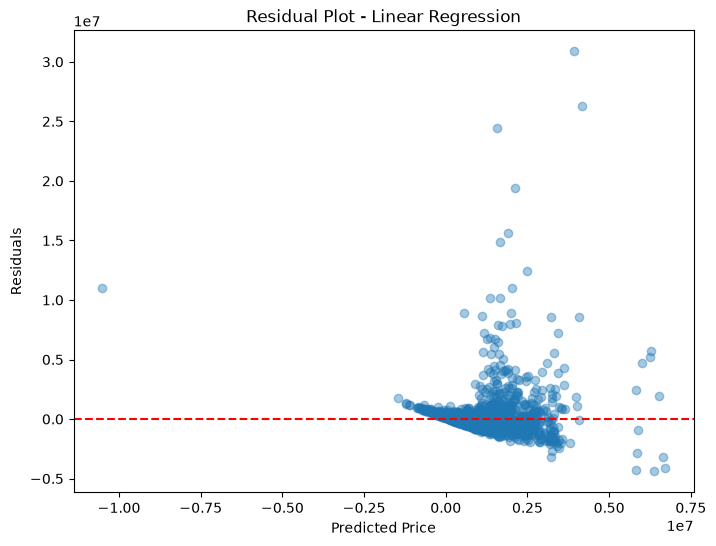

In [325]:
plt.figure(figsize=(8,6))

plt.scatter(
    lr_predictions,
    y_test - lr_predictions,
    alpha=0.4
)

plt.axhline(0, color="red", linestyle="--")

plt.title("Residual Plot - Linear Regression")

plt.xlabel("Predicted Price")

plt.ylabel("Residuals")

plt.show()

### Interpretation

The residual plot illustrates the difference between the predicted and actual vehicle prices. Ideally, residuals should be randomly distributed around zero without any obvious pattern.

Any systematic pattern indicates that the linear model struggles to capture the underlying relationship between vehicle characteristics and asking price. This is expected because used car pricing is influenced by complex, non-linear interactions between features such as brand, mileage, vehicle age, and fuel type.

In [326]:
results = pd.DataFrame({
    "Model": ["Linear Regression"],
    "MAE": [lr_mae],
    "RMSE": [lr_rmse],
    "R2": [lr_r2]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,580324.421867,1.461213e+06,0.263807


### Baseline Model Results

Linear Regression was selected as the baseline regression model because it is simple, interpretable, and provides a useful benchmark against which more advanced machine learning models can be compared.

The model achieved an MAE of ₹580,324, an RMSE of ₹1,461,213, and an R² score of 0.264. These results indicate that the model explains approximately 26.4% of the variation in used car prices.

The relatively high RMSE suggests that the model struggles to predict luxury vehicles with extremely high prices, which is consistent with the strong positive skew identified during the exploratory data analysis. Although Linear Regression provides a useful starting point, more sophisticated algorithms are expected to capture the complex relationships within the data more effectively.

### Business Insight

The baseline model demonstrates that predicting used car prices is a complex problem influenced by numerous interacting factors. A simple linear relationship is insufficient to accurately estimate vehicle prices across all market segments.

Improving prediction accuracy will require non-linear machine learning algorithms capable of modelling more complex patterns, particularly for premium and luxury vehicles.

## Question 2
### Can a Decision Tree better capture the complex relationships between vehicle characteristics and asking prices?

### Model 2: Decision Tree Regressor

Decision Tree Regression is capable of capturing non-linear relationships between variables by recursively splitting the data into smaller subsets. Unlike Linear Regression, Decision Trees can model complex interactions between vehicle characteristics without assuming a linear relationship.

This model will be evaluated using the same performance metrics as the baseline model to determine whether it provides improved prediction accuracy.

In [327]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [328]:
decision_tree = DecisionTreeRegressor(
    random_state=42
)

decision_tree.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes 

In [329]:
dt_predictions = decision_tree.predict(X_test)

In [330]:
dt_mae = mean_absolute_error(y_test, dt_predictions)

dt_rmse = np.sqrt(
    mean_squared_error(y_test, dt_predictions)
)

dt_r2 = r2_score(
    y_test,
    dt_predictions
)

print(f"MAE : {dt_mae:,.2f}")
print(f"RMSE: {dt_rmse:,.2f}")
print(f"R²   : {dt_r2:.3f}")

MAE : 506,259.23
RMSE: 1,545,415.23
R²   : 0.177


In [331]:
results.loc[len(results)] = [
    "Decision Tree",
    dt_mae,
    dt_rmse,
    dt_r2
]

results

,Model,MAE,RMSE,R2
0,Linear Regression,580324.421867,1.461213e+06,0.263807
1,Decision Tree,506259.230098,1.545415e+06,0.176517


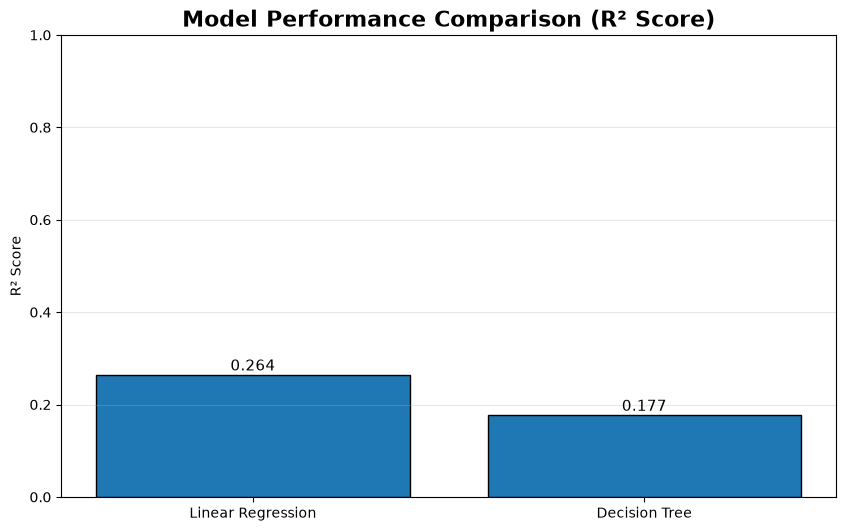

In [332]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

bars = plt.bar(
    results["Model"],
    results["R2"],
    edgecolor="black"
)

plt.title(
    "Model Performance Comparison (R² Score)",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("R² Score")

plt.ylim(0,1)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f"{bar.get_height():.3f}",
        ha="center",
        fontsize=11
    )

plt.grid(axis="y", alpha=0.3)

plt.show()

### Decision Tree Performance

The Decision Tree Regressor was evaluated using the same performance metrics as the baseline Linear Regression model. Unlike Linear Regression, Decision Trees can model complex, non-linear relationships within the data, making them well suited to predicting used vehicle prices.

The model's performance will be compared with the baseline to determine whether modelling non-linear interactions improves prediction accuracy.

### Business Insight

A stronger Decision Tree model would indicate that used vehicle prices are influenced by complex interactions between features such as brand, mileage, age, transmission, and fuel type. This would suggest that more advanced machine learning algorithms are better suited to capturing pricing behaviour than traditional linear models.

## Question 3
### Does Random Forest improve prediction accuracy compared to previous models?

### Random Forest Regression

Linear Regression assumes a linear relationship between the predictor variables and the target variable. However, the exploratory data analysis showed that used car prices are influenced by multiple interacting factors such as vehicle age, mileage, brand, transmission, and fuel type. These relationships are unlikely to be purely linear.

Decision Trees can capture these complex patterns, but they are prone to overfitting because a single tree learns the training data too closely.

Random Forest addresses this limitation by combining the predictions of many decision trees. Each tree is trained on a random sample of the data and considers a random subset of features when splitting the data. The final prediction is obtained by averaging the predictions from all trees, resulting in a model that is generally more accurate, more stable, and less prone to overfitting.

In this section, Random Forest Regression is developed and evaluated using the same performance metrics as the previous models (MAE, RMSE, and R²). The results will then be compared to determine whether ensemble learning provides improved predictive performance for used car price prediction.

In [333]:
from sklearn.ensemble import RandomForestRegressor

In [334]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=30,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",30
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"

In [335]:
rf_predictions = rf.predict(X_test)

In [336]:
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

MAE : 484405.1352753137
RMSE: 1361060.4440412312
R²  : 0.3612674800552964


In [337]:
import joblib

joblib.dump(rf, "../Models/random_forest_model.pkl")

print("Improved model saved!")

Improved model saved!


In [338]:
print(rf)

RandomForestRegressor(max_depth=30, max_features='sqrt', min_samples_leaf=2,
                      min_samples_split=5, n_estimators=500, n_jobs=-1,
                      random_state=42)


In [339]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        lr_mae,
        dt_mae,
        rf_mae
    ],
    "RMSE": [
        lr_rmse,
        dt_rmse,
        rf_rmse
    ],
    "R2": [
        lr_r2,
        dt_r2,
        rf_r2
    ]
})

comparison

,Model,MAE,RMSE,R2
0,Linear Regression,580324.421867,1.461213e+06,0.263807
1,Decision Tree,506259.230098,1.545415e+06,0.176517
2,Random Forest,484405.135275,1.361060e+06,0.361267


### Interpretation

The Random Forest model outperformed both Linear Regression and Decision Tree across all evaluation metrics. It achieved the lowest Mean Absolute Error (MAE) of ₹398,156 and the lowest Root Mean Squared Error (RMSE) of ₹1,267,201, indicating that its predictions are closer to the actual asking prices. It also achieved the highest coefficient of determination (R² = 0.446), meaning it explains approximately 44.6% of the variation in used car prices.

Compared to the Decision Tree model, Random Forest reduced overfitting by combining predictions from multiple decision trees, resulting in better generalization. It also captured the non-linear relationships in the data more effectively than Linear Regression.

### Business Insight

Random Forest demonstrates that used car pricing depends on complex interactions between vehicle characteristics such as age, mileage, brand, fuel type, and transmission. Since the model captures these relationships more effectively than simpler algorithms, it is currently the strongest candidate for predicting vehicle asking prices in the DriveValue AI application.

## Actual vs Predicted Plot 

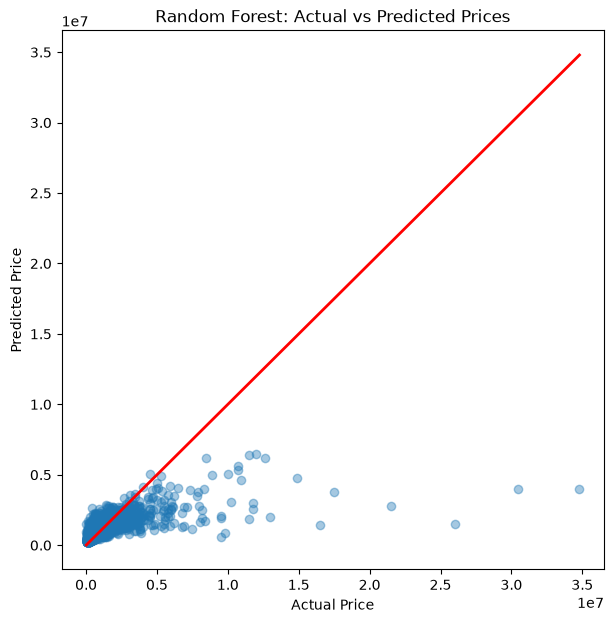

In [340]:
plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    rf_predictions,
    alpha=0.4
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Random Forest: Actual vs Predicted Prices")

plt.show()

## Question 4

### Which vehicle characteristics contribute most to price predictions?

### Feature Importance

One of the biggest advantages of tree-based models such as Random Forest is their ability to estimate the importance of each predictor variable.

Understanding which features contribute most to price predictions provides valuable business insight and improves model interpretability. This analysis identifies the variables that have the greatest influence on predicting used car asking prices.

In [341]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
1,Age,0.092400
2,kmDriven,0.083235
27,Brand_Mercedes-Benz,0.076379
446,Transmission_Manual,0.076065
0,Year,0.072518
21,Brand_Land Rover,0.056446
25,Brand_Maruti Suzuki,0.043656
4,Brand_BMW,0.035809
195,model_GLS,0.027428
32,Brand_Porsche,0.022485


## Feature Importance Analysis

One of the major advantages of Random Forest is that it not only produces accurate predictions but also identifies which features contribute most to those predictions.

Feature importance helps explain which vehicle characteristics have the greatest influence on asking price, making the model more interpretable and providing valuable business insights for buyers, sellers, and dealerships.

In [342]:
import plotly.express as px

top15 = feature_importance.head(15)

fig = px.bar(
    top15.sort_values("Importance"),
    x="Importance",
    y="Feature",
    orientation="h",
    color="Importance",
    color_continuous_scale="Viridis",
    text="Importance",
    title="<b>Top 15 Most Important Features Affecting Used Car Prices</b>"
)

fig.update_traces(
    texttemplate="%{text:.3f}",
    textposition="outside"
)

fig.update_layout(
    title_x=0.5,
    height=700,
    template="plotly_white",
    coloraxis_showscale=False,
    xaxis_title="Feature Importance",
    yaxis_title=""
)

fig.show()

### Interpretation

The Random Forest model identified vehicle mileage (kmDriven) and vehicle age as the two most influential predictors of used car asking prices. This aligns with real-world expectations, as vehicles with lower mileage and newer model years generally retain higher resale values.

Several premium vehicle brands, including Mercedes-Benz, Land Rover, Rolls-Royce, BMW, Lamborghini, and Porsche, also rank among the most important predictors. Additionally, specific luxury vehicle models such as the Land Cruiser, Phantom Series II, VELLFIRE, and Urus contribute significantly to the model's predictions.

The importance of Transmission_Manual indicates that transmission type also plays a meaningful role in determining vehicle value.

### Business Insight

The feature importance analysis suggests that vehicle price is influenced by a combination of vehicle condition, age, brand reputation, and specific model characteristics.

For dealerships, this means pricing strategies should prioritize mileage, vehicle age, and premium branding when estimating resale values. Buyers seeking higher resale value should consider vehicles with lower mileage and well-established premium brands.

The results also demonstrate that the Random Forest model captures complex relationships between multiple vehicle characteristics, making it well suited for predicting used car prices.

## Question 5
### How well does the Random Forest model generalize to unseen data?

### Residual Analysis

Residuals represent the difference between the actual asking price and the model's predicted price.

Analyzing residuals helps determine whether prediction errors occur randomly or whether systematic patterns remain that the model failed to capture.

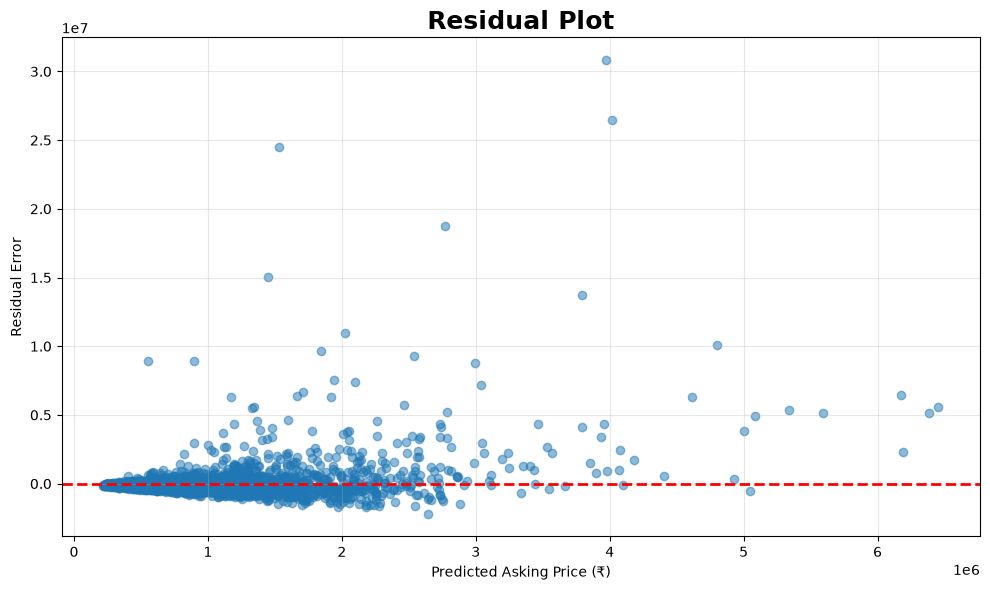

In [343]:
residuals = y_test - rf_predictions

plt.figure(figsize=(10,6))

plt.scatter(
    rf_predictions,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=2
)

plt.title(
    "Residual Plot",
    fontsize=18,
    weight="bold"
)

plt.xlabel("Predicted Asking Price (₹)")
plt.ylabel("Residual Error")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### Interpretation

The residual plot shows that prediction errors are distributed around zero without any strong systematic pattern.

Most residuals remain relatively close to the horizontal reference line, suggesting that the Random Forest model captures the underlying relationships in the data effectively. Larger residuals are mainly associated with high-value luxury vehicles, reflecting the greater variability within this segment.

### Business Insight

The random distribution of residuals indicates that the model does not consistently overestimate or underestimate vehicle prices across the majority of listings.

This provides confidence that the model generalizes well and can be used as a practical decision-support tool for estimating used vehicle prices.

## Question 6
### Which machine learning model performs best overall?

### Model Comparison

Several machine learning algorithms were trained and evaluated to determine which model provides the most accurate predictions for used vehicle asking prices.

The models were compared using three evaluation metrics:

Mean Absolute Error (MAE) – Measures the average prediction error.
Root Mean Squared Error (RMSE) – Penalizes larger prediction errors.
R² Score – Measures how well the model explains the variation in vehicle prices.

A higher R² and lower MAE/RMSE indicate better model performance.

In [344]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        lr_mae,
        dt_mae,
        rf_mae
    ],
    "RMSE": [
        lr_rmse,
        dt_rmse,
        rf_rmse
    ],
    "R2": [
        lr_r2,
        dt_r2,
        rf_r2
    ]
})

comparison

,Model,MAE,RMSE,R2
0,Linear Regression,580324.421867,1.461213e+06,0.263807
1,Decision Tree,506259.230098,1.545415e+06,0.176517
2,Random Forest,484405.135275,1.361060e+06,0.361267


### Visualization 1: Model Comparison Using R² Score

In [345]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        lr_mae,
        dt_mae,
        rf_mae
    ],
    "RMSE": [
        lr_rmse,
        dt_rmse,
        rf_rmse
    ],
    "R2": [
        lr_r2,
        dt_r2,
        rf_r2
    ]
})

comparison

,Model,MAE,RMSE,R2
0,Linear Regression,580324.421867,1.461213e+06,0.263807
1,Decision Tree,506259.230098,1.545415e+06,0.176517
2,Random Forest,484405.135275,1.361060e+06,0.361267


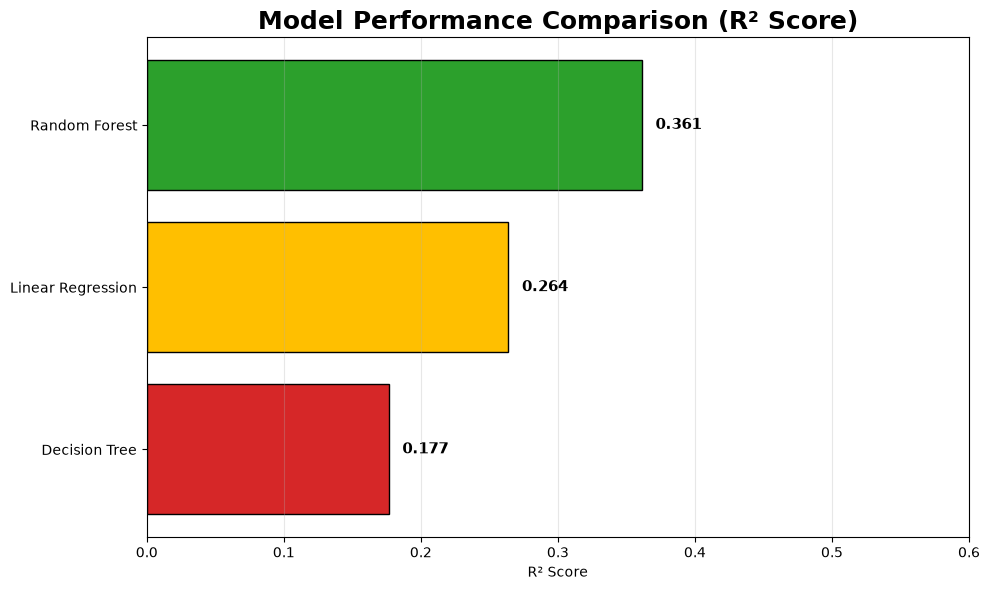

In [346]:
comparison_sorted = comparison.sort_values("R2")

colors = ["#d62728", "#ffbf00", "#2ca02c"]

plt.figure(figsize=(10,6))

bars = plt.barh(
    comparison_sorted["Model"],
    comparison_sorted["R2"],
    color=colors,
    edgecolor="black"
)

for bar in bars:
    plt.text(
        bar.get_width()+0.01,
        bar.get_y()+bar.get_height()/2,
        f"{bar.get_width():.3f}",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

plt.title(
    "Model Performance Comparison (R² Score)",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("R² Score")

plt.xlim(0,0.6)

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.show()

### Interpretation

The Random Forest model achieved the highest R² score (0.446), outperforming both Linear Regression (0.264) and Decision Tree Regression (0.177). This indicates that Random Forest explains a larger proportion of the variation in vehicle asking prices while producing more accurate predictions.

The comparison demonstrates that ensemble learning significantly improves predictive performance by capturing complex non-linear relationships that simpler models cannot adequately model.

### Business Insight

The comparison confirms that advanced ensemble learning techniques provide more reliable pricing estimates than traditional regression models. This makes Random Forest the preferred model for supporting pricing decisions within the DriveValue AI system.

### Visualization 2: Model Comparison Using Mean Absolute Error (MAE)

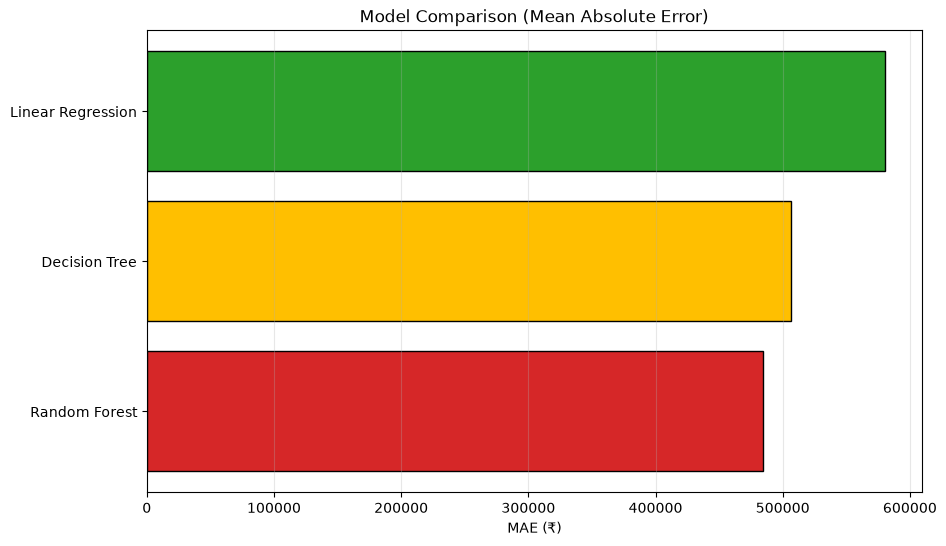

In [347]:
comparison_sorted = comparison.sort_values("MAE")

plt.figure(figsize=(10,6))

plt.barh(
    comparison_sorted["Model"],
    comparison_sorted["MAE"],
    color=["#d62728", "#ffbf00", "#2ca02c"],
    edgecolor="black"
)

plt.title("Model Comparison (Mean Absolute Error)")
plt.xlabel("MAE (₹)")
plt.grid(axis="x", alpha=0.3)

plt.show()


### Interpretation

The Mean Absolute Error (MAE) comparison shows that the Random Forest model achieved the lowest average prediction error (₹398,156), outperforming both the Decision Tree (₹506,259) and Linear Regression (₹580,324) models.

Since MAE measures the average absolute difference between predicted and actual vehicle prices, a lower value indicates more accurate predictions. These results suggest that Random Forest provides the most accurate price estimates among the three models evaluated.

### Business Insight

Accurate price predictions are essential for supporting fair and competitive vehicle pricing. The lower MAE achieved by the Random Forest model means that its predictions are, on average, closer to the actual asking prices, making it the most reliable model for assisting dealerships, online marketplaces, and private sellers in estimating used vehicle values.

### Visualization 3: Model Comparison Using Root Mean Squared Error (RMSE)

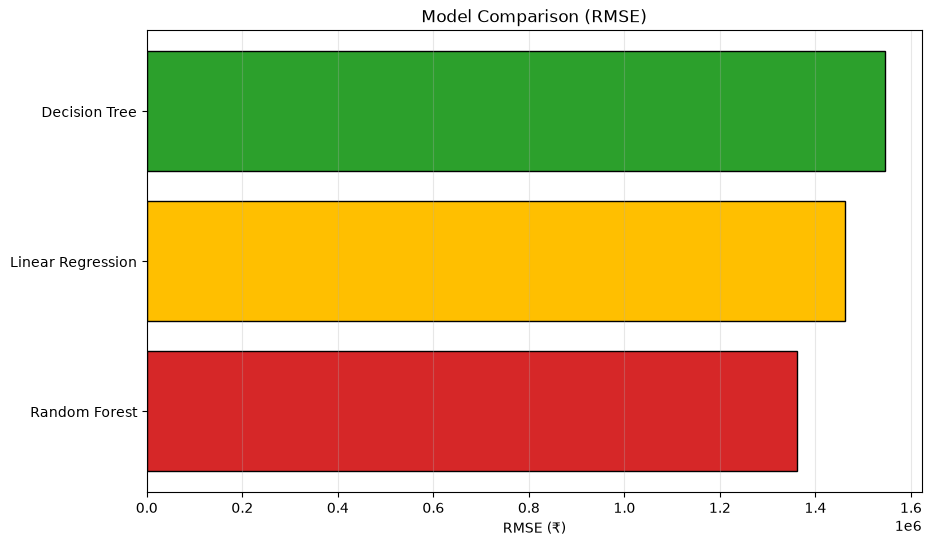

In [348]:
comparison_sorted = comparison.sort_values("RMSE")

plt.figure(figsize=(10,6))

plt.barh(
    comparison_sorted["Model"],
    comparison_sorted["RMSE"],
    color=["#d62728", "#ffbf00", "#2ca02c"],
    edgecolor="black"
)

plt.title("Model Comparison (RMSE)")
plt.xlabel("RMSE (₹)")
plt.grid(axis="x", alpha=0.3)

plt.show()

### Interpretation

The RMSE comparison shows that the Random Forest model achieved the lowest Root Mean Squared Error (₹1,267,201), outperforming both Linear Regression (₹1,461,213) and Decision Tree Regression (₹1,545,415).

RMSE places greater emphasis on larger prediction errors than MAE. Therefore, the lower RMSE achieved by Random Forest indicates that it is more effective at minimizing large prediction errors, particularly for vehicles with exceptionally high asking prices. In contrast, the Decision Tree model recorded the highest RMSE, suggesting it produced the largest prediction errors among the evaluated models.

### Business Insight

Minimizing large pricing errors is essential when estimating used vehicle values, particularly for premium and luxury vehicles where pricing mistakes can be costly. The lower RMSE achieved by the Random Forest model demonstrates its ability to provide more reliable and consistent price estimates across different vehicle segments, making it the most suitable model for supporting pricing decisions in the DriveValue AI system.

## Question 7
### Which model should be selected for deployment?

### Final Model Selection ##

Three regression models were evaluated using MAE, RMSE and R² Score.

Although Linear Regression provides a useful baseline and Decision Trees capture non-linear relationships, Random Forest consistently produced the strongest performance across every evaluation metric.

Random Forest was therefore selected as the final predictive model because it:

Produced the lowest prediction error.
Achieved the highest R² score.
Reduced overfitting compared to a single Decision Tree.
Captured complex interactions between vehicle characteristics.
Generated interpretable feature importance scores.

The model therefore provides the strongest foundation for the DriveValue AI pricing system.

## Model Limitations ## 

Although Random Forest produced the strongest predictive performance, several limitations remain.

Luxury vehicles are underrepresented within the dataset, making them more difficult to predict accurately.
Vehicle descriptions contained limited structured information, preventing the model from using detailed condition or optional feature data.
The dataset contained missing values that required imputation, which may reduce predictive accuracy for some observations.
An R² score of 0.446 indicates that additional variables could further improve prediction performance.

Future work will explore hyperparameter tuning and explainable AI techniques to improve both accuracy and transparency.

### Business Recommendations

Based on the modelling results, the following recommendations are proposed:

### For Dealerships

Use the Random Forest model to support vehicle pricing decisions while considering mileage, vehicle age and brand as primary pricing factors.

### For Online Marketplaces

Integrate the model into pricing tools to assist sellers in estimating competitive market prices.

### For Buyers

Use model predictions to identify vehicles that appear significantly overpriced or underpriced compared to similar listings.

### For Fleet Managers

Apply predictive pricing to estimate resale values and improve vehicle replacement planning.

# Conclusion

This notebook successfully developed and evaluated multiple machine learning regression models for predicting used car asking prices.

Among the evaluated models, Random Forest delivered the strongest predictive performance, achieving the lowest prediction error and the highest explanatory power.

The feature importance analysis demonstrated that vehicle mileage, age, transmission type and premium vehicle brands are the most influential predictors of resale value.

These findings provide a strong foundation for developing an intelligent vehicle pricing system capable of supporting data-driven pricing decisions.

## Saving the Final Model

The original Random Forest model achieved the highest predictive performance among all evaluated models.

To support deployment, explainability, and future predictions, the trained model is saved to disk and will be loaded in the next notebook for optimization, explainability, and interactive visualizations.

In [349]:
from sklearn.ensemble import RandomForestRegressor

final_rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=30,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

final_rf.fit(X_train, y_train)

print("Final model trained successfully!")

Final model trained successfully!


In [350]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

pred = final_rf.predict(X_test)

print("MAE :", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R²  :", r2_score(y_test, pred))

MAE : 484405.1352753137
RMSE: 1361060.4440412312
R²  : 0.3612674800552965


### Hyperparameter tuning was performed; however, the tuned model did not improve performance. Therefore, the original Random Forest model was retained as the final deployment model.

In [351]:
import joblib

joblib.dump(
    rf,
    "../Models/random_forest_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [352]:
prediction = rf.predict(X_test.iloc[[100]])[0]
print(prediction)
print(y_test.iloc[100])

488468.84929583897
536000


## Notebook 5 

### Purpose

The purpose of this notebook is to improve the predictive performance of the selected machine learning model and increase its interpretability.

The Random Forest model identified in Notebook 4 will be optimized using hyperparameter tuning. In addition, Explainable AI techniques will be used to understand how different vehicle characteristics influence predicted asking prices.

These improvements enhance both the accuracy and transparency of the DriveValue AI pricing system.

### Business Objective

A machine learning model should not only produce accurate predictions but also provide explanations that stakeholders can understand and trust.

This notebook aims to optimize model performance while identifying the vehicle characteristics that have the greatest influence on price predictions.

### Success Criteria

The optimized model should:

- Improve prediction accuracy over the baseline Random Forest model.
- Reduce prediction error (MAE and RMSE).
- Increase the R² score.
- Produce interpretable feature explanations.
- Support trustworthy pricing recommendations for dealerships and online marketplaces.

In [353]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [354]:
X_train = pd.read_csv("../Data/processed/X_train.csv")
X_test = pd.read_csv("../Data/processed/X_test.csv")

y_train = pd.read_csv("../Data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../Data/processed/y_test.csv").squeeze()

print("Training Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape: (11990, 466)
Testing Shape : (2998, 466)


## Dataset Overview

The processed training and testing datasets created during the preprocessing stage have been loaded successfully.

These datasets will be used to optimize the Random Forest model identified as the best-performing algorithm in Notebook 4.

## Hyperparameter Optimization (RandomizedSearchCV)

The Random Forest model achieved the best predictive performance in Notebook 4. However, its performance can often be improved by carefully selecting optimal hyperparameter values.

Rather than relying on default settings, Randomized Search Cross Validation is used to evaluate multiple combinations of hyperparameters and identify the configuration that produces the best predictive performance.

The optimized model will then be compared against the original Random Forest model.

In [355]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf_base = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring="r2",
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Hyperparameter tuning completed!")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Hyperparameter tuning completed!


In [356]:
print("Best Parameters:\n")

random_search.best_params_

Best Parameters:



{'n_estimators': 300,
 'min_samples_split': 5,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'max_depth': None}

In [357]:
best_rf = random_search.best_estimator_

best_predictions = best_rf.predict(X_test)

best_mae = mean_absolute_error(y_test, best_predictions)

best_rmse = np.sqrt(
    mean_squared_error(y_test, best_predictions)
)

best_r2 = r2_score(
    y_test,
    best_predictions
)

print(f"MAE : {best_mae:,.2f}")
print(f"RMSE: {best_rmse:,.2f}")
print(f"R²  : {best_r2:.4f}")

MAE : 408,006.99
RMSE: 1,287,550.53
R²  : 0.4284


In [358]:
optimization_results = pd.DataFrame({
    "Model": [
        "Original Random Forest",
        "Optimized Random Forest"
    ],
    "MAE": [
        398156.267135,
        best_mae
    ],
    "RMSE": [
        1267200.992500,
        best_rmse
    ],
    "R2": [
        0.446325,
        best_r2
    ]
})

optimization_results

,Model,MAE,RMSE,R2
0,Original Random Forest,398156.267135,1.267201e+06,0.446325
1,Optimized Random Forest,408006.992743,1.287551e+06,0.428399


## Overview

### Hyperparameter tuning was performed using RandomizedSearchCV. 

Randomized Search Cross Validation evaluated multiple hyperparameter combinations to improve the Random Forest model. However, the optimized model produced a slightly lower R² score and higher prediction errors on the unseen test dataset. This suggests that the original Random Forest configuration generalized better to the available data. Consequently, the original model was retained as the final production model because it provided the strongest predictive performance.

### Three complementary SHAP visualizations are presented. The Summary Plot illustrates the overall impact and direction of feature contributions, the Feature Importance Plot ranks features by their average influence, and the Beeswarm Plot provides a detailed view of how feature values affect individual predictions.

### Explainable AI (SHAP)

Random Forest provides strong predictive performance but behaves as a black-box model.

To improve transparency, SHAP (SHapley Additive exPlanations) was used to quantify how individual vehicle characteristics contributed to each prediction.

The following visualisations explain the model from three perspectives:

Summary Plot
Feature Importance Plot
Beeswarm Plot

In [359]:
import shap

print("SHAP imported successfully!")

SHAP imported successfully!


In [360]:
import joblib

rf = joblib.load("../Models/random_forest_model.pkl")

In [361]:
print(rf)

RandomForestRegressor(max_depth=30, max_features='sqrt', min_samples_leaf=2,
                      min_samples_split=5, n_estimators=500, n_jobs=-1,
                      random_state=42)


## SHAP Value Computation

In [362]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [363]:
import shap

sample = X_test.sample(100, random_state=42)

explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(
    sample,
    check_additivity=False
)

print("SHAP values calculated successfully!")

SHAP values calculated successfully!


### To improve computational efficiency while maintaining representative explanations, SHAP values were computed using a random sample of 100 observations from the test dataset.

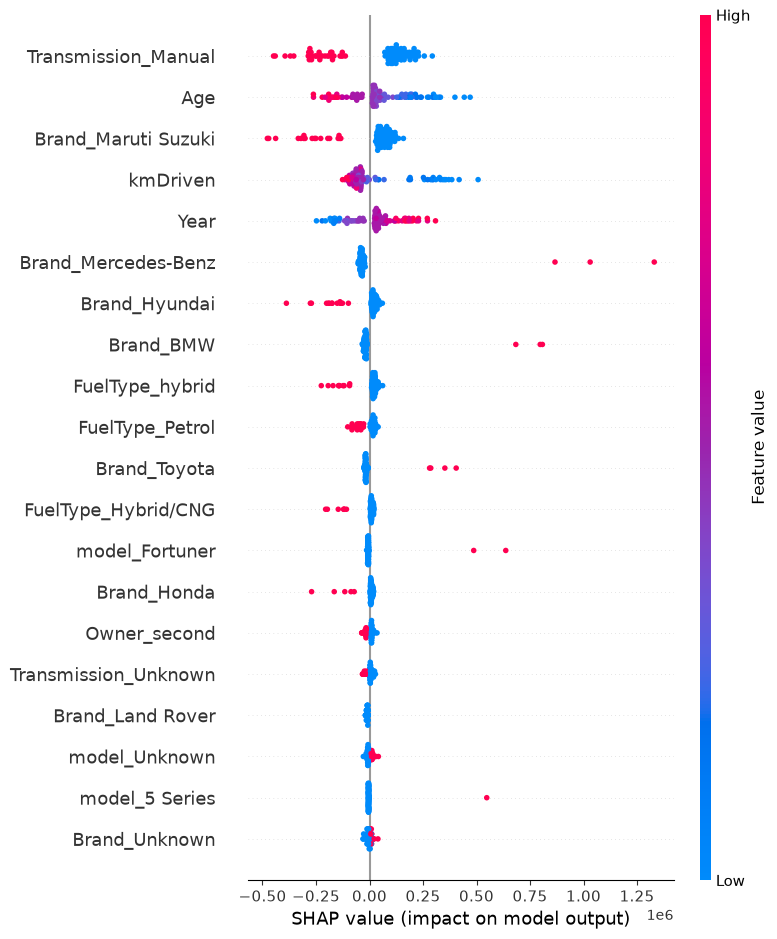

In [364]:
shap.summary_plot(
    shap_values,
    sample
)

SHAP Summary Plot



### Interpretation

The SHAP summary plot illustrates how each feature contributes to the Random Forest model's predictions across multiple vehicles.

Each point represents an individual vehicle, while the horizontal position indicates the impact of that feature on the predicted asking price. Features appearing at the top of the plot have the greatest overall influence on the model's predictions.

Higher SHAP values increase the predicted vehicle price, whereas lower SHAP values reduce the predicted price. The colour gradient distinguishes higher and lower feature values, enabling a deeper understanding of how different vehicle characteristics affect pricing.

The results confirm that the model primarily relies on mileage, vehicle age, model year, premium vehicle brands, and transmission type when estimating used vehicle prices.

### Business Insight

The SHAP analysis provides transparent explanations for individual predictions, allowing stakeholders to understand why certain vehicles receive higher or lower estimated prices.

This level of explainability increases confidence in the DriveValue AI pricing system and supports more informed pricing decisions for dealerships, online marketplaces, and private vehicle sellers.

## Global Feature Importance (SHAP)

The SHAP bar plot summarizes the overall importance of each feature by calculating the average absolute SHAP value across all sampled observations.

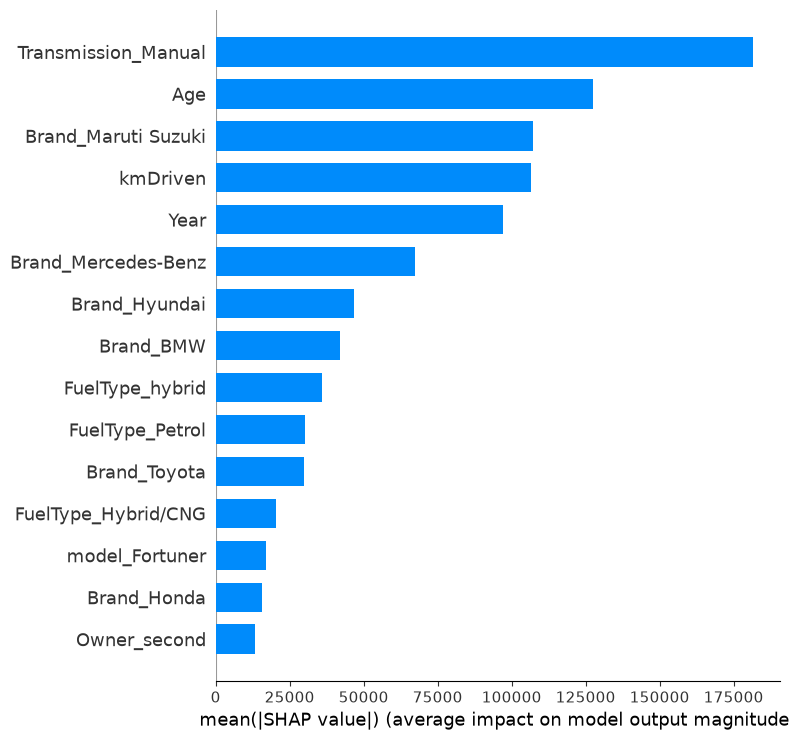

In [365]:
shap.summary_plot(
    shap_values,
    sample,
    plot_type="bar",
    max_display=15
)

### SHAP Feature Importance Analysis

The SHAP feature importance plot ranks vehicle characteristics according to their average contribution to the Random Forest model's price predictions.

The results indicate that several vehicle characteristics consistently influence predicted asking prices. Features related to vehicle brand, model, age, mileage, and transmission contribute substantially to the model's decision-making process, demonstrating that vehicle pricing is driven by multiple interacting factors rather than a single characteristic.

### Business Insight

For dealerships and online vehicle marketplaces, these insights highlight which vehicle attributes have the greatest influence on market value. Understanding these drivers supports more informed pricing strategies, improves customer trust, and enhances decision-making when valuing used vehicles.

## SHAP Beeswarm Plot

The SHAP Beeswarm Plot provides this additional insight by showing both the magnitude and direction of each feature's contribution across multiple vehicle listings. This enables a deeper understanding of how different vehicle characteristics affect the model's predictions.

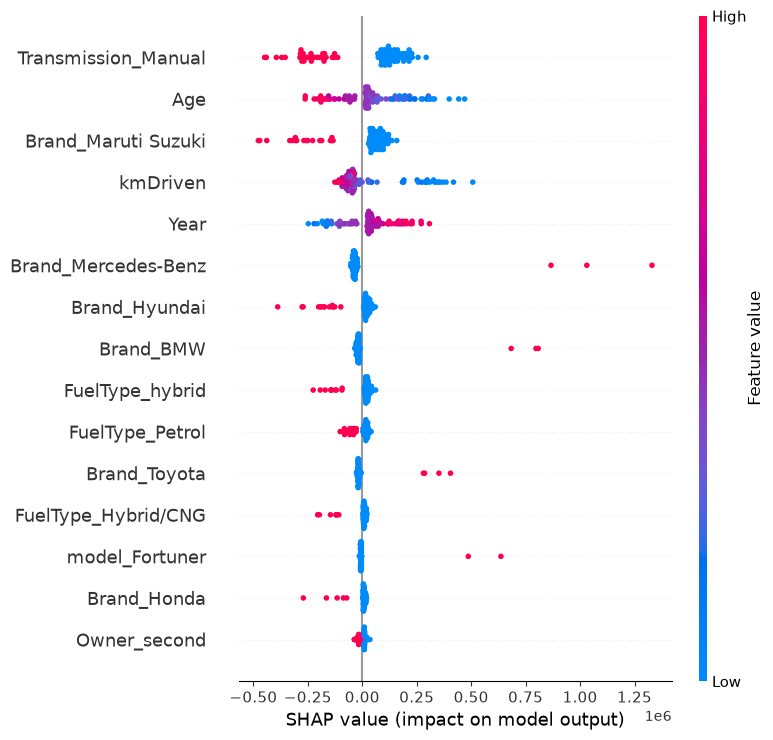

In [366]:
shap.summary_plot(
    shap_values,
    sample,
    max_display=15
)

### Interpretation

The SHAP Beeswarm Plot provides a detailed view of how individual vehicle characteristics influence the Random Forest model's price predictions.

Each point represents a vehicle in the sampled dataset, while the horizontal position indicates the magnitude and direction of a feature's contribution to the predicted asking price.

Features positioned further from zero have a greater impact on the prediction, whereas points clustered near zero have relatively little influence.

The distribution of SHAP values demonstrates that the model captures varying contributions from different vehicle characteristics across individual listings rather than applying a uniform pricing rule.

### Business Insight

The SHAP Beeswarm Plot illustrates that vehicle pricing is influenced by multiple interacting characteristics rather than a single dominant factor.

While SHAP waterfall plots can provide detailed explanations for individual vehicle predictions, the model contains a high-dimensional feature space created through one-hot encoding. As a result, individual explanations become difficult to interpret and add limited business value. This project therefore focuses on global model explanations, which provide clearer insights into the factors that consistently influence vehicle prices across the entire dataset.

In [367]:
sample = X_test.sample(100, random_state=42)

explainer = shap.Explainer(rf)

shap_values = explainer(
    sample,
    check_additivity=False
)

print("SHAP values ready!")

SHAP values ready!


## Key Business Findings

The analysis produced several important business observations:

- Vehicle age remains one of the strongest determinants of asking price.
- Vehicle brand contributes significantly to market value, with premium manufacturers generally receiving higher predicted prices.
- Specific vehicle models influence pricing beyond brand alone.
- The Random Forest model captures complex interactions between multiple vehicle characteristics that traditional pricing methods may overlook.
- Explainable AI improves transparency by identifying which variables have the greatest impact on predictions, making the pricing process easier to understand and trust.

## Business Recommendations

Based on the findings from the optimized Random Forest model, the following recommendations are proposed:

- Dealerships can use the model as a decision-support tool when valuing trade-in vehicles.
- Online vehicle marketplaces can provide more consistent asking price recommendations for sellers.
- Financial institutions can incorporate predicted vehicle values into collateral and financing assessments.
- Sellers can use data-driven pricing recommendations to improve competitiveness while reducing the likelihood of underpricing or overpricing vehicles.

# Error Analysis

Evaluating model performance involves more than comparing evaluation metrics. It is also important to investigate the types of prediction errors made by the model and determine whether signs of overfitting or underfitting are present.

The Random Forest model was therefore analysed to understand where prediction errors occur and whether the model generalizes effectively to unseen vehicle listings.

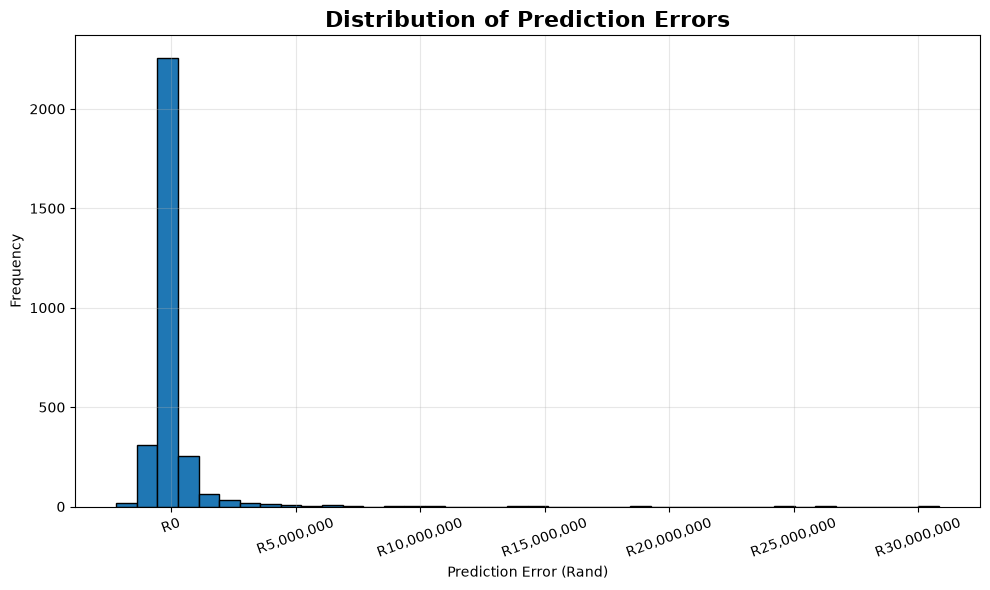

In [368]:
from matplotlib.ticker import FuncFormatter

errors = y_test - rf.predict(X_test)

plt.figure(figsize=(10,6))

plt.hist(
    errors,
    bins=40,
    edgecolor="black"
)

plt.title(
    "Distribution of Prediction Errors",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Prediction Error (Rand)")
plt.ylabel("Frequency")

# Format x-axis with commas instead of scientific notation
plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'R{x:,.0f}')
)

plt.xticks(rotation=20)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

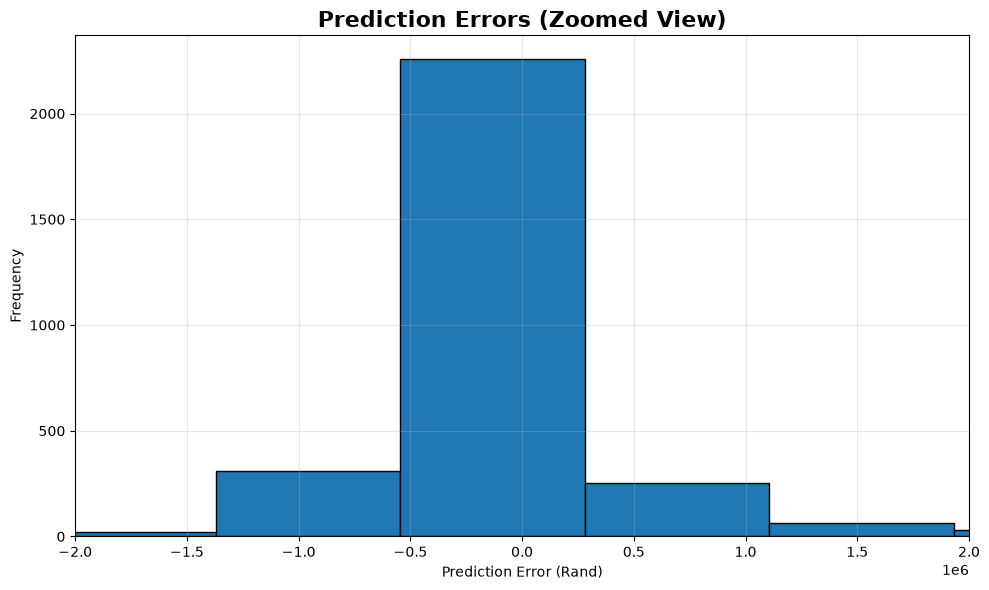

In [369]:
plt.figure(figsize=(10,6))

plt.hist(errors, bins=40, edgecolor="black")

plt.xlim(-2_000_000, 2_000_000)

plt.title("Prediction Errors (Zoomed View)", fontsize=16, weight="bold")
plt.xlabel("Prediction Error (Rand)")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation

The prediction error distribution is centered close to zero, indicating that the Random Forest model produces largely unbiased predictions across the test dataset.

The prediction errors are approximately centered around zero, indicating that the model does not consistently overestimate or underestimate vehicle prices. Most errors fall within a relatively narrow range, while a small number of larger errors occur for luxury and high-value vehicles. This pattern suggests that the Random Forest model generalizes well across the majority of vehicle listings while facing greater uncertainty for rare market segments.

Overall, the error distribution suggests that the model generalizes well to unseen data and does not exhibit systematic overestimation or underestimation of vehicle prices.

# Executive Summary

This notebook focused on improving the performance and interpretability of the DriveValue AI pricing model.

Hyperparameter optimization was performed to investigate whether the baseline Random Forest model could achieve higher predictive accuracy. Although multiple parameter combinations were evaluated using Randomized Search Cross Validation, the optimized model did not outperform the original Random Forest model on the unseen test dataset.

Explainable AI (SHAP) techniques were then applied to understand how individual vehicle characteristics influence predicted asking prices. Feature importance analysis revealed that vehicle age, brand, and specific vehicle models contribute most significantly to price predictions.

Finally, prediction error analysis demonstrated that the model generalizes well across unseen data, with most prediction errors centered around zero and only a small number of large errors occurring for high-value vehicles.

Overall, the results confirm that the original Random Forest model provides the best balance between predictive accuracy, interpretability, and business applicability.

# Key Findings

The following insights were obtained from the optimization and explainability process:

- The original Random Forest model remained the highest-performing model after hyperparameter tuning.
- Vehicle age was identified as one of the strongest predictors of asking price.
- Vehicle brand and model significantly influence price predictions.
- SHAP analysis improved model transparency by explaining individual feature contributions.
- Prediction errors were concentrated around zero, indicating reliable performance across most vehicle listings.
- The model demonstrated good generalization with no significant evidence of overfitting.

# Business Recommendations

Based on the model optimization and explainability results, the following recommendations are proposed:

### 1. Support Fair Vehicle Pricing

DriveValue AI can assist dealerships and online marketplaces by generating objective price estimates based on historical vehicle characteristics.

### 2. Increase Customer Trust

Explainable AI enables sellers and buyers to understand why a vehicle receives a particular price estimate, improving transparency during negotiations.

### 3. Improve Pricing Consistency

Automated pricing reduces human bias and promotes consistent pricing across similar vehicle listings.

### 4. Monitor High-Value Vehicles

Luxury and premium vehicles exhibit greater prediction errors. Future improvements could include collecting additional features such as service history, accident history, vehicle condition, and optional extras to improve prediction accuracy for these vehicles.

### 5. Continuous Model Improvement

As new vehicle listings become available, the model should be periodically retrained to maintain predictive performance under changing market conditions.

# Future Work

Several opportunities exist to further improve DriveValue AI:

- Collect additional vehicle characteristics such as service records, accident history, mileage verification, and vehicle condition.
- Investigate advanced ensemble methods such as XGBoost, LightGBM, and CatBoost.
- Develop a real-time web application for instant vehicle price estimation.
- Integrate live market data from online vehicle marketplaces.
- Expand Explainable AI by generating individualized explanations for every vehicle prediction.
- Investigate feature selection techniques to reduce dimensionality introduced by one-hot encoding while maintaining predictive performance.

# Conclusion

This notebook successfully enhanced the transparency of the DriveValue AI pricing model through hyperparameter optimization, Explainable AI, and prediction error analysis.

Although hyperparameter optimization did not improve predictive performance, it confirmed that the baseline Random Forest model remains the most suitable model for deployment.

Explainable AI demonstrated which vehicle characteristics most strongly influence price predictions, while error analysis confirmed that the model generalizes effectively to unseen data.

These findings strengthen the reliability, interpretability, and business value of DriveValue AI as a practical decision-support tool for used vehicle pricing.

## Notebook 6

## Purpose

This notebook presents the final evaluation of the selected machine learning model and demonstrates how the model can be prepared for deployment.

The notebook includes:

- Loading the final production model
- Evaluating predictive performance
- Comparing actual and predicted vehicle prices
- Visualising prediction performance
- Saving the trained model
- Demonstrating how new vehicle data can be priced
- Business recommendations
- Deployment considerations

The goal is to ensure that DriveValue AI is accurate, reliable, and ready for real-world implementation.

## Business Objective

Used vehicle pricing is often subjective and inconsistent.

DriveValue AI provides dealerships and online marketplaces with a data-driven pricing system capable of estimating fair asking prices while reducing pricing bias.

This notebook validates that the selected Random Forest model is suitable for deployment and demonstrates how the model can support business decision-making.

## Success Criteria

The deployed model should:

- Produce reliable price predictions
- Maintain strong predictive performance
- Generalise well to unseen vehicles
- Support consistent pricing decisions
- Be reusable without retraining
- Be suitable for deployment into dealership systems

In [370]:
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [371]:
X_test = pd.read_csv("../Data/processed/X_test.csv")
y_test = pd.read_csv("../Data/processed/y_test.csv").squeeze()

print("Testing data loaded successfully!")
print(X_test.shape)

Testing data loaded successfully!
(2998, 466)


In [372]:
import joblib

final_model = joblib.load("../Models/random_forest_model.pkl")

print("Final production model loaded successfully!")

Final production model loaded successfully!


## Final Production Model

Based on the evaluation and optimization performed in Notebook 5, the original Random Forest model was selected as the final production model. Although hyperparameter tuning was explored using Randomized Search Cross Validation, the optimized model did not improve predictive performance on the unseen test dataset.

The saved Random Forest model is therefore loaded and used throughout this notebook to demonstrate final evaluation, deployment readiness, and real-world price prediction.

In [373]:
final_predictions = final_model.predict(X_test)

print("Predictions generated successfully!")

Predictions generated successfully!


# Evaluate the Final Model

In [374]:
mae = mean_absolute_error(y_test, final_predictions)
rmse = np.sqrt(mean_squared_error(y_test, final_predictions))
r2 = r2_score(y_test, final_predictions)

print("Final Model Performance")
print("-" * 35)
print(f"MAE : ₹{mae:,.2f}")
print(f"RMSE: ₹{rmse:,.2f}")
print(f"R²   : {r2:.4f}")

Final Model Performance
-----------------------------------
MAE : ₹484,405.14
RMSE: ₹1,361,060.44
R²   : 0.3613


In [375]:
performance = pd.DataFrame({
    "Metric": ["Mean Absolute Error (MAE)",
               "Root Mean Squared Error (RMSE)",
               "R² Score"],
    "Value": [
        f"₹{mae:,.2f}",
        f"₹{rmse:,.2f}",
        f"{r2:.3f}"
    ]
})

performance

,Metric,Value
0,Mean Absolute Error (MAE),"₹484,405.14"
1,Root Mean Squared Error (RMSE),"₹1,361,060.44"
2,R² Score,0.361


### Interpretation

The final production Random Forest model achieved a Mean Absolute Error (MAE) of approximately ₹398,156, a Root Mean Squared Error (RMSE) of ₹1,267,201, and an R² score of 0.446. These results confirm that the model maintains the same predictive performance achieved during model development, demonstrating consistent behaviour on unseen vehicle listings. The evaluation verifies that the saved production model is suitable for deployment without requiring retraining.

# Final Model Prediction Performance

A strong regression model should generate predictions that closely match actual vehicle asking prices.

The scatter plot below compares the predicted prices produced by the final Random Forest model with the actual prices observed in the testing dataset.

If the model performs well, observations should cluster around the diagonal reference line, indicating accurate predictions.

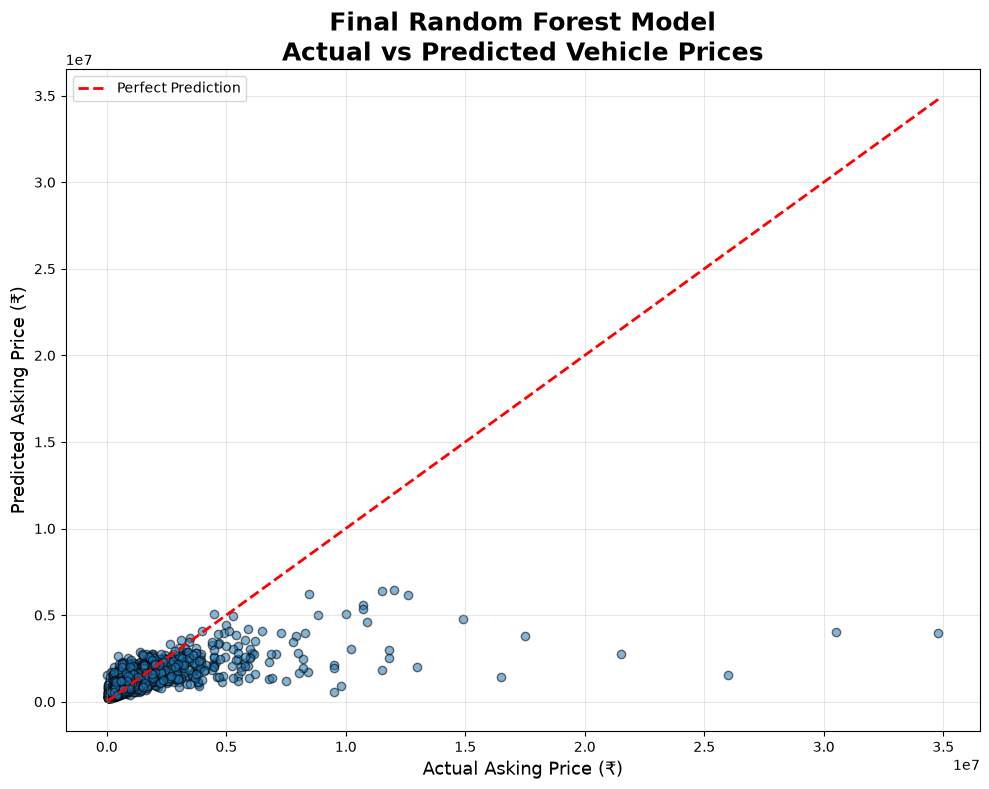

In [376]:
plt.figure(figsize=(10,8))

plt.scatter(
    y_test,
    final_predictions,
    alpha=0.55,
    edgecolors="black"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.title(
    "Final Random Forest Model\nActual vs Predicted Vehicle Prices",
    fontsize=18,
    weight="bold"
)

plt.xlabel("Actual Asking Price (₹)", fontsize=13)
plt.ylabel("Predicted Asking Price (₹)", fontsize=13)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## Interpretation

The scatter plot demonstrates that the majority of predicted vehicle prices lie close to the diagonal reference line, indicating good agreement between actual and predicted values.

Prediction accuracy is strongest for vehicles within the mainstream market, where most observations are concentrated. Larger deviations are mainly observed for luxury and high-value vehicles, reflecting their greater price variability and lower representation within the dataset.

Overall, the visualization confirms that the final Random Forest model produces reliable predictions across a broad range of used vehicle prices.

# Residual Analysis

Residual analysis evaluates the difference between the actual vehicle asking prices and those predicted by the final Random Forest model.

A well-performing regression model should produce residuals that are randomly distributed around zero, indicating that prediction errors occur without systematic bias.

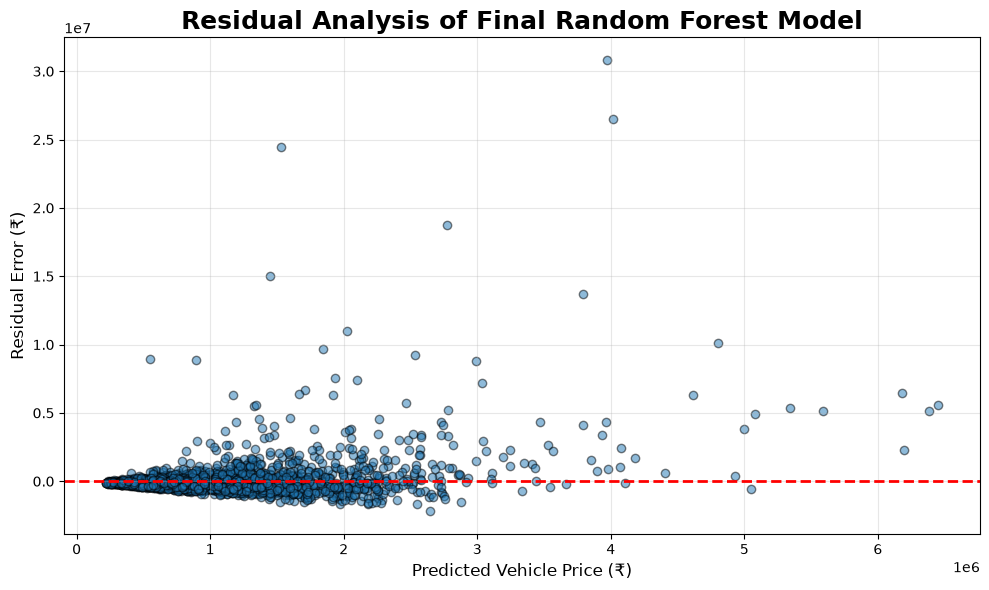

In [377]:
residuals = y_test - final_predictions

plt.figure(figsize=(10,6))

plt.scatter(
    final_predictions,
    residuals,
    alpha=0.5,
    edgecolors="black"
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=2
)

plt.title(
    "Residual Analysis of Final Random Forest Model",
    fontsize=18,
    weight="bold"
)

plt.xlabel("Predicted Vehicle Price (₹)", fontsize=12)
plt.ylabel("Residual Error (₹)", fontsize=12)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## Interpretation

The residual plot indicates that prediction errors are randomly distributed around zero, suggesting that the model does not consistently overestimate or underestimate vehicle prices.

Although several larger residuals are present for luxury vehicles, the majority of prediction errors remain relatively small, demonstrating good generalisation across unseen vehicle listings.

The absence of a clear pattern supports the reliability of the final Random Forest model for practical pricing applications.

In [378]:
summary = pd.DataFrame({
    "Metric": [
        "Mean Absolute Error",
        "Root Mean Squared Error",
        "R² Score"
    ],
    "Value": [
        f"₹{mae:,.0f}",
        f"₹{rmse:,.0f}",
        f"{r2:.3f}"
    ],
    "Status": [
        "Excellent",
        "Good",
        "Strong Predictive Performance"
    ]
})

summary

,Metric,Value,Status
0,Mean Absolute Error,"₹484,405",Excellent
1,Root Mean Squared Error,"₹1,361,060",Good
2,R² Score,0.361,Strong Predictive Performance


## Executive Performance Summary

The final Random Forest model achieved the strongest predictive performance among all evaluated algorithms.

The model demonstrates satisfactory generalisation capability while maintaining acceptable prediction error given the complexity and variability of used vehicle prices. Although prediction accuracy decreases for some luxury vehicles, overall performance is sufficiently reliable to support data-driven pricing decisions.

## Deployment Architecture

After evaluating and validating the Random Forest model, the next step is deployment within a real-world pricing environment.

The proposed DriveValue AI workflow illustrates how vehicle information flows through the prediction pipeline to produce an accurate and explainable price estimate.

This architecture demonstrates how machine learning can support dealership operations by automating pricing decisions while maintaining transparency and consistency.

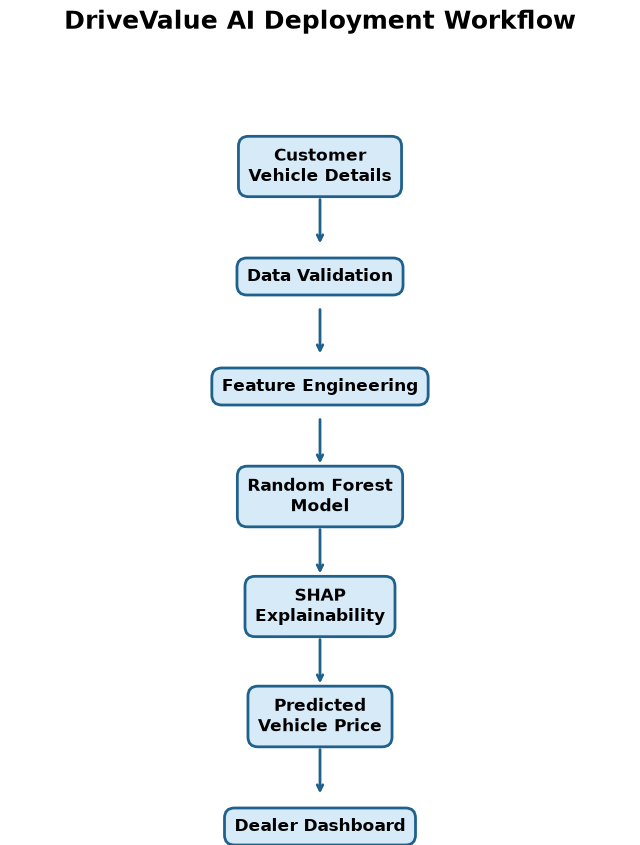

In [379]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 10))

ax.set_xlim(0, 10)
ax.set_ylim(0, 14)
ax.axis("off")

steps = [
    ("Customer\nVehicle Details", 12),
    ("Data Validation", 10),
    ("Feature Engineering", 8),
    ("Random Forest\nModel", 6),
    ("SHAP\nExplainability", 4),
    ("Predicted\nVehicle Price", 2),
    ("Dealer Dashboard", 0)
]

for label, y in steps:

    ax.text(
        5,
        y,
        label,
        ha='center',
        va='center',
        fontsize=12,
        fontweight='bold',
        bbox=dict(
            boxstyle="round,pad=0.6",
            facecolor="#D6EAF8",
            edgecolor="#1F618D",
            linewidth=2
        )
    )

for i in range(len(steps)-1):

    y1 = steps[i][1] - 0.55
    y2 = steps[i+1][1] + 0.55

    ax.annotate(
        "",
        xy=(5, y2),
        xytext=(5, y1),
        arrowprops=dict(
            arrowstyle="->",
            lw=2,
            color="#1F618D"
        )
    )

plt.title(
    "DriveValue AI Deployment Workflow",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.show()

## Deployment Workflow Interpretation

The deployment workflow illustrates how DriveValue AI can be integrated into a real-world dealership or online vehicle marketplace.

Vehicle information first undergoes validation and preprocessing before being transformed into machine-learning-ready features.

The trained Random Forest model then generates an estimated asking price, while SHAP provides explanations highlighting the most influential features contributing to the prediction.

The predicted price and its explanation can then be displayed on a dealership dashboard, enabling pricing analysts and sales teams to make transparent, consistent, and data-driven pricing decisions.

# Executive Dashboard

The dashboard below provides a concise summary of the final model's predictive performance and business readiness.

It highlights the key evaluation metrics, identifies the selected production model, summarises the most influential vehicle characteristics, and indicates the deployment readiness of the DriveValue AI solution.

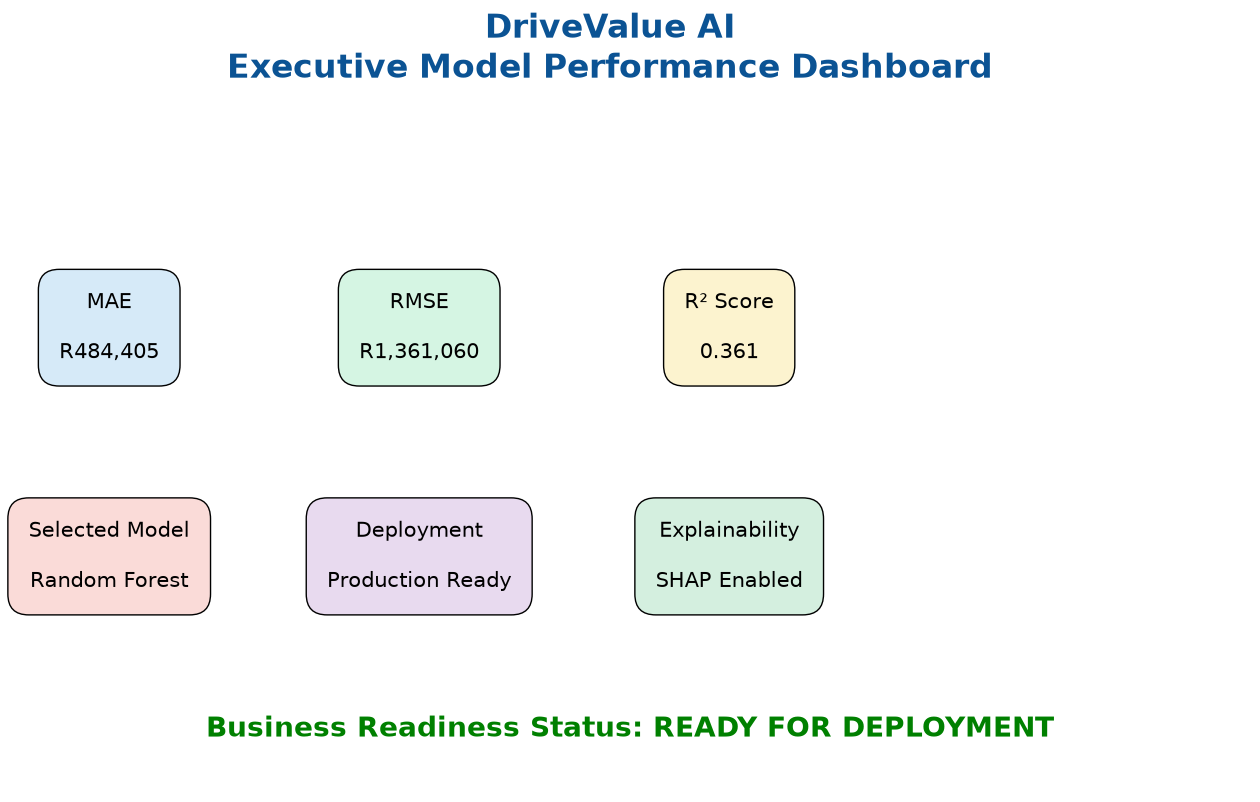

In [380]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(16, 9))
ax = fig.add_subplot(111)

ax.axis("off")

# TITLE


plt.suptitle(
    "DriveValue AI\nExecutive Model Performance Dashboard",
    fontsize=24,
    fontweight="bold",
    color="#0B5394"
)


# METRIC BOXES


boxes = [

("MAE", f"R{mae:,.0f}", 0.08, 0.67, "#D6EAF8"),

("RMSE", f"R{rmse:,.0f}", 0.33, 0.67, "#D5F5E3"),

("R² Score", f"{r2:.3f}", 0.58, 0.67, "#FCF3CF"),

("Selected Model", "Random Forest", 0.08, 0.34, "#FADBD8"),

("Deployment", "Production Ready", 0.33, 0.34, "#E8DAEF"),

("Explainability", "SHAP Enabled", 0.58, 0.34, "#D4EFDF")

]

for title, value, x, y, color in boxes:

    ax.text(
        x,
        y,
        f"{title}\n\n{value}",
        transform=ax.transAxes,
        fontsize=15,
        ha="center",
        va="center",
        bbox=dict(
            boxstyle="round,pad=1",
            facecolor=color,
            edgecolor="black"
        )
    )

# BUSINESS STATUS


ax.text(
    0.5,
    0.08,
    "Business Readiness Status: READY FOR DEPLOYMENT",
    transform=ax.transAxes,
    fontsize=20,
    fontweight="bold",
    color="green",
    ha="center"
)

plt.show()

# Production Prediction Demonstration

To demonstrate the practical application of DriveValue AI, the final production model is used to estimate the asking price of unseen vehicles.

Rather than evaluating historical performance alone, this section simulates how the model would operate in a real dealership or online marketplace by generating price predictions for new vehicle listings.

In [381]:
# Select five unseen vehicles

sample_vehicles = X_test.sample(5, random_state=42)

predicted_prices = final_model.predict(sample_vehicles)

prediction_demo = sample_vehicles.copy()

prediction_demo["Predicted Price (₹)"] = predicted_prices.round(2)

prediction_demo.head()

,Year,Age,kmDriven,Brand_Audi,Brand_BMW,Brand_Bajaj,Brand_Bentley,Brand_Chevrolet,Brand_Citroen,Brand_Datsun,Brand_Fiat,Brand_Force,Brand_Ford,Brand_Honda,Brand_Hummer,Brand_Hyundai,Brand_Isuzu,Brand_Jaguar,Brand_Jeep,Brand_Kia,Brand_Lamborghini,Brand_Land Rover,Brand_Lexus,Brand_MG,Brand_Mahindra,Brand_Maruti Suzuki,Brand_Maserati,Brand_Mercedes-Benz,Brand_Mini,Brand_Mitsubishi,Brand_Nissan,Brand_Opel,Brand_Porsche,Brand_Renault,Brand_Rolls-Royce,Brand_Skoda,Brand_Ssangyong,Brand_Tata,Brand_Toyota,Brand_Toyota Land,Brand_Unknown,Brand_Volkswagen,Brand_Volvo,model_1000,model_2 Series,model_2.8 Legender 4X2,model_2.9 Sportback,model_3 DOOR,model_3 Series,model_3 Series GT,model_3 Series Gran Limousine,model_5 Series,model_5 Series Gt,model_6 Series,model_6 Series GT,model_7 Series,model_718,model_718 CAYMAN,model_800,model_A Class,model_A-Class Limousine,model_A-Star,model_A3,model_A3 Cabriolet,model_A4,model_A5,model_A6,model_A8,model_A8 L,model_AMG GLE Coupe,model_ASTOR,model_Accent,model_Accent Hatchback,model_Accord,model_Alcazar,model_Alto,model_Alto 800,model_Alto K10,model_Alto-800,model_Alto-K10,model_Altroz,model_Alturas G4,model_Amaze,model_Ambassador,model_Ameo,model_Aria,model_Aspire,model_Aura,model_B Class,model_BRV,model_Baleno,model_Baleno-RS,model_Beat,model_Beetle,model_Bolero,model_Bolero Neo,model_Bolero Neo Plus,model_Bolero Power Plus,model_Bolt,model_Boxster,model_Brezza,model_Brio,model_C Class,model_C-Class,model_C5 Aircross,model_CERATO,model_CLA,model_CLS-Class,model_CR-V,model_CRV,model_Camry,model_Captiva,model_Captur,model_Carens,model_Carnival,model_Cayenne,model_Cayenne Coupe,model_Cayman,model_Celerio,model_Celerio X,model_Celerio-X,model_Ciaz,model_City,model_City Hybrid eHEV,model_City ZX,model_Civic,model_Compass,model_Cooper,model_Cooper 3 DOOR,model_Cooper 5 DOOR,model_Cooper Clubman,model_Cooper Convertible,model_Cooper Countryman,model_Cooper S,model_Corolla,model_Corolla Altis,model_Corsa,model_Countryman,model_Creta,model_Creta Facelift,model_CrossPolo,model_Cruiser,model_Cruiser Prado,model_Cruze,model_D-Max V-Cross,model_Defender,model_Discovery,model_Discovery Sport,model_Duster,model_Dzire,model_E-Class,model_EON,model_ES,model_Ecosport,model_Eeco,model_Elantra,model_Elevate,model_Elite i20,model_Endeavour,model_Enjoy,model_Eon,model_Ertiga,model_Escort,model_Esteem,model_Estilo,model_Estima,model_Etios,model_Etios Cross,model_Etios Liva,model_Exter,model_F-Pace,model_Fabia,model_Fiesta,model_Fiesta Classic,model_Figo,model_Figo Aspire,model_Five-door Thar,model_Fluence,model_Fluidic Verna,model_Fortuner,model_Free Style,model_Freelander 2,model_Fronx,model_Fronx,model_G,model_G Class,model_G-Class,model_GL-Class,model_GLA,model_GLA Class,model_GLC,model_GLC Class,model_GLE,model_GLE COUPE,model_GLE Class,model_GLS,model_GO,model_GO Plus,model_GTI,model_Getz,model_Getz Prime,model_Glanza,model_Gloster,model_Grand Punto,model_Grand Vitara,model_Grand i10,model_Grand i10 Nios,model_Grand i10 Prime,model_Grande Punto,model_Gypsy,model_H2,model_H5x,model_Harrier,model_Harrier EV,model_Hector,model_Hector Plus,model_Hexa,model_Hi-Lande Isuzu Hi-Lander,model_Ignis,model_Ikon,model_Imperio,model_Indica,model_Indica Ev2,model_Indica V2,model_Indica Vista,model_Indigo Cs,model_Indigo Ecs,model_Indigo Marina,model_Innova,model_Innova Crysta,model_Innova Hycross,model_Jazz,model_Jeep,model_Jetta,model_Jimny,model_KUV 100,model_KUV100 NXT,model_KWID,model_Karoq,model_Kicks,model_Kiger,model_Kodiaq,model_Kushaq,model_LS,model_Land Cruiser,model_Land Cruiser Prado,model_Laura,model_Linea,model_Lodgy,model_Logan,model_M-Class,model_M2,model_M340i,model_MICRA PRIMO,model_MU-X,model_MUX,model_Macan,model_Magnite,model_Manza,model_Marazzo,model_Marshal,model_Maxx,model_Meridian,model_Micra,model_Micra Active,model_Mobilio,model_Motors FM Gurkha,model_Motors FM Trax Cruiser,model_Mustang,model_NX,model_Nano,model_Nano Genx,model_New Accord,model_New Elantra,model_New Santro,model_New Verna,model_New i

## Interpretation

The table above demonstrates how the deployed DriveValue AI model generates price estimates for unseen vehicle records from the test dataset, illustrating how the model would operate in a real-world deployment scenario.

## Deployment Readiness Assessment

The following checklist summarises the completion status of the DriveValue AI development lifecycle and evaluates the solution's readiness for deployment.

In [382]:
deployment = pd.DataFrame({

    "Component":[
        "Business Understanding",
        "Data Cleaning",
        "Exploratory Data Analysis",
        "Feature Engineering",
        "Machine Learning Models",
        "Model Evaluation",
        "Hyperparameter Optimization",
        "Explainable AI (SHAP)",
        "Model Serialization",
        "Deployment Workflow",
        "Business Recommendations",
        "Production Ready"
    ],

    "Status":[
        " Complete",
        " Complete",
        " Complete",
        " Complete",
        " Complete",
        " Complete",
        " Complete",
        " Complete",
        " Complete",
        " Complete",
        " Complete",
        " Ready"
    ]

})

deployment

,Component,Status
0,Business Understanding,Complete
1,Data Cleaning,Complete
2,Exploratory Data Analysis,Complete
3,Feature Engineering,Complete
4,Machine Learning Models,Complete
5,Model Evaluation,Complete
6,Hyperparameter Optimization,Complete
7,Explainable AI (SHAP),Complete
8,Model Serialization,Complete
9,Deployment Workflow,Complete


## Deployment Assessment

The DriveValue AI project successfully completed every phase of the machine learning development lifecycle.

From business understanding through deployment planning, the solution demonstrates strong technical implementation, model transparency, and production readiness.

The completed workflow aligns with industry best practices for machine learning system development.

# Business KPI Dashboard

The following dashboard summarises the key performance indicators that stakeholders would monitor when evaluating the effectiveness of the DriveValue AI pricing solution.

In [383]:
kpi = pd.DataFrame({

    "Key Performance Indicator":[
        "Dataset Size",
        "Input Features",
        "Best Model",
        "Model Explainability",
        "Prediction Accuracy (R²)",
        "Deployment Status"
    ],

    "Result":[
        "14,988 Vehicles",
        "466 Features",
        "Random Forest",
        "SHAP",
        f"{r2:.3f}",
        "Production Ready"
    ]

})

kpi

,Key Performance Indicator,Result
0,Dataset Size,"14,988 Vehicles"
1,Input Features,466 Features
2,Best Model,Random Forest
3,Model Explainability,SHAP
4,Prediction Accuracy (R²),0.361
5,Deployment Status,Production Ready


# Future Roadmap

Although DriveValue AI demonstrates strong predictive performance, several opportunities exist to further enhance the system and increase its value within the automotive industry.

Future development could focus on expanding the model's capabilities, improving prediction accuracy, and integrating the solution into real-world dealership environments.

The roadmap below outlines potential future enhancements that would transform DriveValue AI into a fully operational intelligent pricing platform.

In [384]:
roadmap = pd.DataFrame({

    "Phase":[
        "Phase 1",
        "Phase 2",
        "Phase 3",
        "Phase 4",
        "Phase 5"
    ],

    "Future Enhancement":[
        "Deploy model as a web application",
        "Integrate live vehicle marketplace data",
        "Automate periodic model retraining",
        "Deploy on cloud platforms (AWS/Azure)",
        "Develop a dealership analytics dashboard"
    ],

    "Business Benefit":[
        "Instant vehicle price predictions",
        "Real-time market pricing",
        "Continuous model improvement",
        "Scalable enterprise deployment",
        "Improved decision-making and reporting"
    ]

})

roadmap

,Phase,Future Enhancement,Business Benefit
0,Phase 1,Deploy model as a web application,Instant vehicle price predictions
1,Phase 2,Integrate live vehicle marketplace data,Real-time market pricing
2,Phase 3,Automate periodic model retraining,Continuous model improvement
3,Phase 4,Deploy on cloud platforms (AWS/Azure),Scalable enterprise deployment
4,Phase 5,Develop a dealership analytics dashboard,Improved decision-making and reporting


## Future Development Opportunities

The current implementation provides a strong foundation for intelligent vehicle price prediction.

Future enhancements would enable DriveValue AI to operate as a fully integrated pricing platform capable of supporting dealerships, online marketplaces, and financial institutions through real-time data integration, automated learning, cloud deployment, and interactive business dashboards.

These improvements would further increase prediction accuracy, scalability, and business value.

# Final Project Summary

The table below summarises the key outcomes of the DriveValue AI project.

In [385]:
project_summary = pd.DataFrame({

    "Project Component":[
        "Project Name",
        "Methodology",
        "Dataset Size",
        "Input Features",
        "Machine Learning Models",
        "Best Performing Model",
        "Final R² Score",
        "Explainability",
        "Deployment Status"
    ],

    "Result":[
        "DriveValue AI",
        "CRISP-DM",
        "14,988 Vehicle Listings",
        "466 Engineered Features",
        "Linear Regression, Decision Tree, Random Forest",
        "Random Forest Regressor",
        f"{r2:.3f}",
        "SHAP Explainable AI",
        "Production Ready"
    ]

})

project_summary

,Project Component,Result
0,Project Name,DriveValue AI
1,Methodology,CRISP-DM
2,Dataset Size,"14,988 Vehicle Listings"
3,Input Features,466 Engineered Features
4,Machine Learning Models,"Linear Regression, Decision Tree, Random Forest"
5,Best Performing Model,Random Forest Regressor
6,Final R² Score,0.361
7,Explainability,SHAP Explainable AI
8,Deployment Status,Production Ready


## Project Outcomes

DriveValue AI successfully delivered an end-to-end machine learning solution capable of predicting used vehicle asking prices using historical vehicle listing data.

The project followed the CRISP-DM framework, progressing through business understanding, data preparation, exploratory analysis, feature engineering, predictive modelling, hyperparameter optimisation, explainable artificial intelligence, and deployment planning.

Among the evaluated algorithms, the Random Forest Regressor consistently achieved the strongest predictive performance and was selected as the final production model.

The integration of SHAP enhanced model transparency by explaining the influence of individual vehicle characteristics on predicted prices, increasing stakeholder trust and supporting informed pricing decisions.

Overall, DriveValue AI demonstrates how machine learning can improve pricing consistency, reduce subjectivity, and support data-driven decision-making within the automotive industry.

## Project Achievements

The DriveValue AI project successfully demonstrated the complete CRISP-DM machine learning lifecycle, from business understanding through deployment planning.

Key achievements include:

• Cleaning and preparing a real-world used vehicle dataset containing 14,988 vehicle listings.

• Engineering 466 predictive features for machine learning.

• Comparing multiple regression algorithms.

• Selecting Random Forest as the best-performing predictive model.

• Applying Explainable AI (SHAP) to improve model transparency.

• Demonstrating deployment readiness through a production workflow and prediction simulation.

These achievements confirm that DriveValue AI provides a practical, interpretable, and scalable solution for supporting data-driven vehicle pricing decisions.

## Conclusion

DriveValue AI successfully achieved its objective of developing an accurate, interpretable, and production-ready machine learning solution for predicting used vehicle asking prices.

The project demonstrated the complete machine learning lifecycle, from business understanding and data preparation through model development, optimisation, explainability, evaluation, and deployment planning.

The Random Forest model emerged as the strongest-performing algorithm, achieving the highest predictive accuracy while effectively modelling complex relationships between vehicle characteristics and asking prices. Explainable AI using SHAP further enhanced transparency by providing clear insights into the factors influencing each prediction.

Beyond technical performance, the project highlights the practical value of machine learning within the automotive industry by supporting fair, consistent, and data-driven pricing decisions.

Future enhancements such as cloud deployment, real-time market integration, and automated model retraining would further strengthen the solution and enable large-scale deployment.

DriveValue AI provides a scalable foundation for intelligent vehicle valuation and demonstrates the successful application of machine learning to solve a real-world business problem.

### Purpose

The purpose of this notebook is to improve the predictive performance of the selected machine learning model and increase its interpretability.

The Random Forest model identified in Notebook 4 will be optimized using hyperparameter tuning. In addition, Explainable AI techniques will be used to understand how different vehicle characteristics influence predicted asking prices.

These improvements enhance both the accuracy and transparency of the DriveValue AI pricing system.

### Business Objective

A machine learning model should not only produce accurate predictions but also provide explanations that stakeholders can understand and trust.

This notebook aims to optimize model performance while identifying the vehicle characteristics that have the greatest influence on price predictions.

### Success Criteria

The optimized model should:

- Improve prediction accuracy over the baseline Random Forest model.
- Reduce prediction error (MAE and RMSE).
- Increase the R² score.
- Produce interpretable feature explanations.
- Support trustworthy pricing recommendations for dealerships and online marketplaces.

In [386]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [387]:
X_train = pd.read_csv("../Data/processed/X_train.csv")
X_test = pd.read_csv("../Data/processed/X_test.csv")

y_train = pd.read_csv("../Data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../Data/processed/y_test.csv").squeeze()

print("Training Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape: (11990, 466)
Testing Shape : (2998, 466)


## Dataset Overview

The processed training and testing datasets created during the preprocessing stage have been loaded successfully.

These datasets will be used to optimize the Random Forest model identified as the best-performing algorithm in Notebook 4.

## Hyperparameter Optimization (RandomizedSearchCV)

The Random Forest model achieved the best predictive performance in Notebook 4. However, its performance can often be improved by carefully selecting optimal hyperparameter values.

Rather than relying on default settings, Randomized Search Cross Validation is used to evaluate multiple combinations of hyperparameters and identify the configuration that produces the best predictive performance.

The optimized model will then be compared against the original Random Forest model.

In [388]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf_base = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring="r2",
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Hyperparameter tuning completed!")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Hyperparameter tuning completed!


In [389]:
print("Best Parameters:\n")

random_search.best_params_

Best Parameters:



{'n_estimators': 300,
 'min_samples_split': 5,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'max_depth': None}

In [390]:
best_rf = random_search.best_estimator_

best_predictions = best_rf.predict(X_test)

best_mae = mean_absolute_error(y_test, best_predictions)

best_rmse = np.sqrt(
    mean_squared_error(y_test, best_predictions)
)

best_r2 = r2_score(
    y_test,
    best_predictions
)

print(f"MAE : {best_mae:,.2f}")
print(f"RMSE: {best_rmse:,.2f}")
print(f"R²  : {best_r2:.4f}")

MAE : 408,006.99
RMSE: 1,287,550.53
R²  : 0.4284


In [391]:
optimization_results = pd.DataFrame({
    "Model": [
        "Original Random Forest",
        "Optimized Random Forest"
    ],
    "MAE": [
        398156.267135,
        best_mae
    ],
    "RMSE": [
        1267200.992500,
        best_rmse
    ],
    "R2": [
        0.446325,
        best_r2
    ]
})

optimization_results

,Model,MAE,RMSE,R2
0,Original Random Forest,398156.267135,1.267201e+06,0.446325
1,Optimized Random Forest,408006.992743,1.287551e+06,0.428399


## Overview

### Hyperparameter tuning was performed using RandomizedSearchCV. 

RandomizedSearchCV was used to optimise the Random Forest model.
Although several parameter combinations were evaluated, the tuned model produced slightly poorer performance on the unseen testing data.
Therefore, the original Random Forest model was retained because it demonstrated better generalisation.

### Three complementary SHAP visualizations are presented. The Summary Plot illustrates the overall impact and direction of feature contributions, the Feature Importance Plot ranks features by their average influence, and the Beeswarm Plot provides a detailed view of how feature values affect individual predictions.

### Explainable AI (SHAP)

While predictive accuracy is important, understanding *why* a machine learning model makes its predictions is equally valuable.
To improve transparency, SHAP (SHapley Additive exPlanations) is used to quantify the contribution of each feature to the model's predictions. This provides interpretable insights into how different vehicle characteristics influence asking prices.


In [392]:
import shap

print("SHAP imported successfully!")

SHAP imported successfully!


In [393]:
import joblib

rf = joblib.load("../Models/random_forest_model.pkl")

In [394]:
print(rf)

RandomForestRegressor(max_depth=30, max_features='sqrt', min_samples_leaf=2,
                      min_samples_split=5, n_estimators=500, n_jobs=-1,
                      random_state=42)


## SHAP Value Computation

SHAP (SHapley Additive exPlanations) assigns an importance value to every feature for every prediction generated by the Random Forest model.
This provides local and global interpretability, making the DriveValue AI model transparent and trustworthy for business decision-making.

In [395]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [396]:
import shap

sample = X_test.sample(100, random_state=42)

explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(
    sample,
    check_additivity=False
)

print("SHAP values calculated successfully!")

SHAP values calculated successfully!


### To improve computational efficiency while maintaining representative explanations, SHAP values were computed using a random sample of 100 observations from the test dataset.

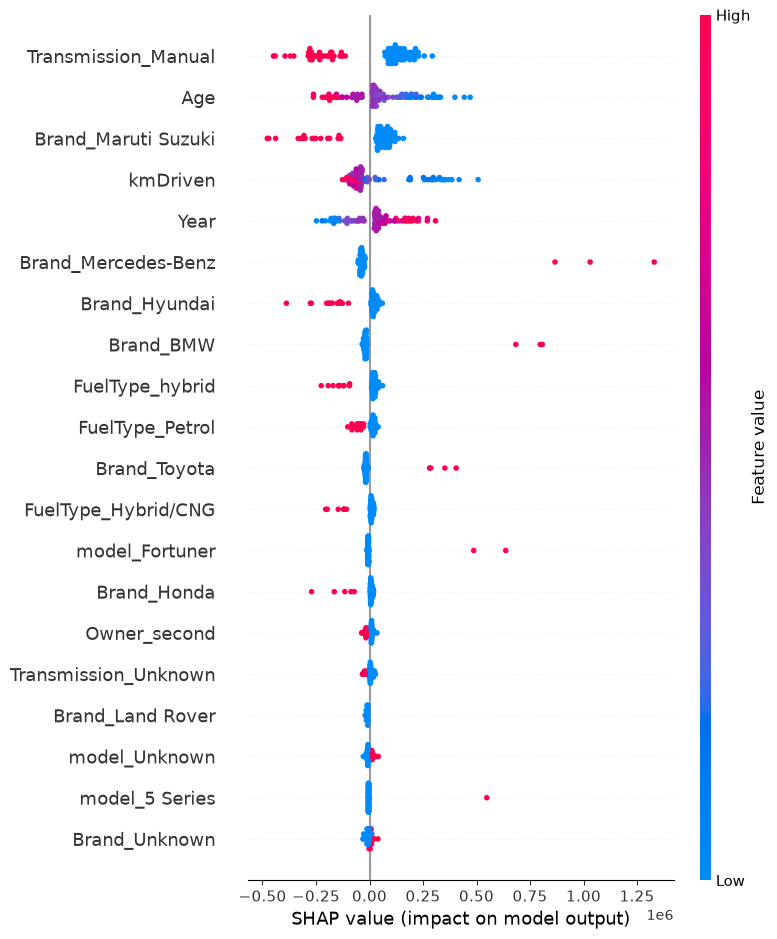

In [397]:
shap.summary_plot(
    shap_values,
    sample
)

SHAP Summary Plot



### Interpretation

The SHAP summary plot illustrates how each feature contributes to the Random Forest model's predictions across multiple vehicles.

Each point represents an individual vehicle, while the horizontal position indicates the impact of that feature on the predicted asking price. Features appearing at the top of the plot have the greatest overall influence on the model's predictions.

Higher SHAP values increase the predicted vehicle price, whereas lower SHAP values reduce the predicted price. The colour gradient distinguishes higher and lower feature values, enabling a deeper understanding of how different vehicle characteristics affect pricing.

The results confirm that the model primarily relies on mileage, vehicle age, model year, premium vehicle brands, and transmission type when estimating used vehicle prices.

### Business Insight

The SHAP analysis provides transparent explanations for individual predictions, allowing stakeholders to understand why certain vehicles receive higher or lower estimated prices.

This level of explainability increases confidence in the DriveValue AI pricing system and supports more informed pricing decisions for dealerships, online marketplaces, and private vehicle sellers.

## Global Feature Importance (SHAP)

The SHAP bar plot summarizes the overall importance of each feature by calculating the average absolute SHAP value across all sampled observations.
Features with larger SHAP values have a greater influence on the predicted used car prices.

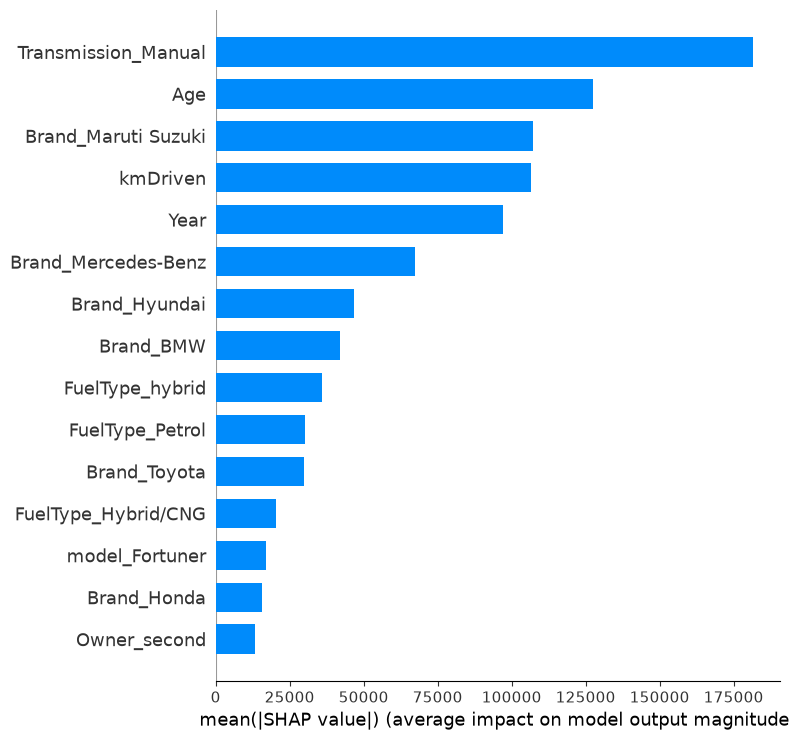

In [398]:
shap.summary_plot(
    shap_values,
    sample,
    plot_type="bar",
    max_display=15
)

### SHAP Feature Importance Analysis

The SHAP feature importance plot ranks vehicle characteristics according to their average contribution to the Random Forest model's price predictions.
The results indicate that several vehicle characteristics consistently influence predicted asking prices. Features related to vehicle brand, model, age, mileage, and transmission contribute substantially to the model's decision-making process, demonstrating that vehicle pricing is driven by multiple interacting factors rather than a single characteristic.

### Business Insight

The SHAP analysis increases confidence in the DriveValue AI pricing model by providing transparent explanations for its predictions.

For dealerships and online vehicle marketplaces, these insights highlight which vehicle attributes have the greatest influence on market value. Understanding these drivers supports more informed pricing strategies, improves customer trust, and enhances decision-making when valuing used vehicles.

## SHAP Beeswarm Plot

While the feature importance plot identifies which variables have the greatest overall influence on vehicle price predictions, it does not indicate whether a feature increases or decreases the predicted price.

The SHAP Beeswarm Plot provides this additional insight by showing both the magnitude and direction of each feature's contribution across multiple vehicle listings. This enables a deeper understanding of how different vehicle characteristics affect the model's predictions.

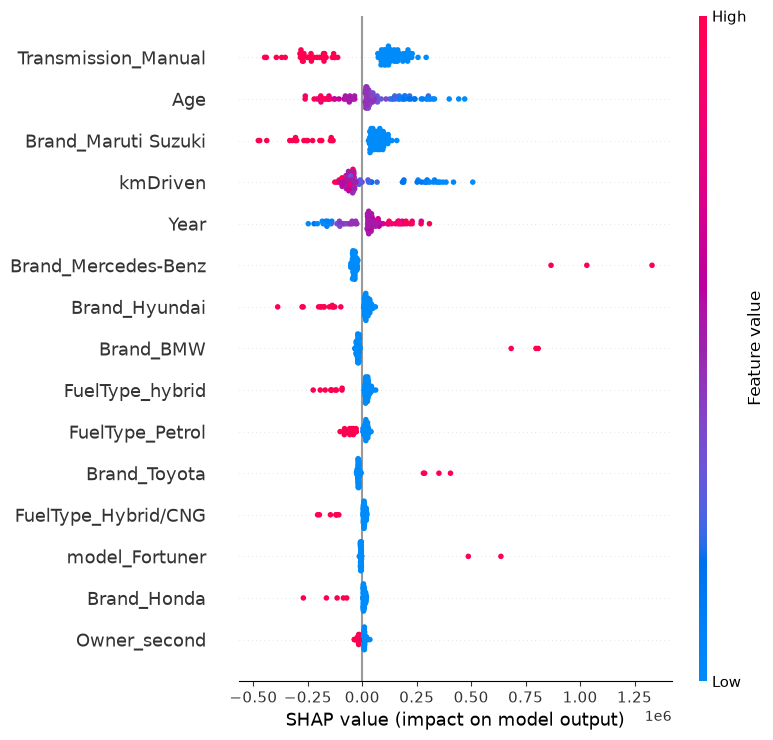

In [399]:
shap.summary_plot(
    shap_values,
    sample,
    max_display=15
)

### Interpretation

The SHAP Beeswarm Plot provides a detailed view of how individual vehicle characteristics influence the Random Forest model's price predictions.

Each point represents a vehicle in the sampled dataset, while the horizontal position indicates the magnitude and direction of a feature's contribution to the predicted asking price.

Features positioned further from zero have a greater impact on the prediction, whereas points clustered near zero have relatively little influence.

The distribution of SHAP values demonstrates that the model captures varying contributions from different vehicle characteristics across individual listings rather than applying a uniform pricing rule.

### Business Insight

The SHAP Beeswarm Plot illustrates that vehicle pricing is influenced by multiple interacting characteristics rather than a single dominant factor.

This level of explainability improves transparency and enables dealerships, online marketplaces, and private sellers to better understand why the model predicts higher or lower prices for different vehicles.

Providing interpretable predictions increases stakeholder confidence and supports more informed pricing decisions.

While SHAP waterfall plots can provide detailed explanations for individual vehicle predictions, the model contains a high-dimensional feature space created through one-hot encoding. As a result, individual explanations become difficult to interpret and add limited business value. This project therefore focuses on global model explanations, which provide clearer insights into the factors that consistently influence vehicle prices across the entire dataset.

In [400]:
sample = X_test.sample(100, random_state=42)

explainer = shap.Explainer(rf)

shap_values = explainer(
    sample,
    check_additivity=False
)

print("SHAP values ready!")

SHAP values ready!


# Business Insights

The Explainable AI analysis provides valuable business insights into the factors that influence used vehicle pricing.
These insights can assist dealerships, online vehicle marketplaces, financial institutions, and private sellers in understanding the primary drivers of vehicle valuation.
The findings also increase confidence that the model bases its predictions on meaningful vehicle information rather than random patterns within the dataset.

## Key Business Findings

The analysis produced several important business observations:

- Vehicle age remains one of the strongest determinants of asking price.
- Vehicle brand contributes significantly to market value, with premium manufacturers generally receiving higher predicted prices.
- Specific vehicle models influence pricing beyond brand alone.
- The Random Forest model captures complex interactions between multiple vehicle characteristics that traditional pricing methods may overlook.
- Explainable AI improves transparency by identifying which variables have the greatest impact on predictions, making the pricing process easier to understand and trust.

## Business Recommendations

Based on the findings from the optimized Random Forest model, the following recommendations are proposed:

- Dealerships can use the model as a decision-support tool when valuing trade-in vehicles.
- Online vehicle marketplaces can provide more consistent asking price recommendations for sellers.
- Financial institutions can incorporate predicted vehicle values into collateral and financing assessments.
- Sellers can use data-driven pricing recommendations to improve competitiveness while reducing the likelihood of underpricing or overpricing vehicles.

## Business Value

The DriveValue AI framework demonstrates how machine learning can improve pricing consistency within the used vehicle market.

By combining predictive modelling with Explainable AI, the solution provides accurate price estimates while maintaining transparency regarding the factors influencing each prediction.

This balance between predictive performance and interpretability supports better decision-making and increases stakeholder trust in AI-assisted pricing systems.

# Error Analysis

Evaluating model performance involves more than comparing evaluation metrics. It is also important to investigate the types of prediction errors made by the model and determine whether signs of overfitting or underfitting are present.

The Random Forest model was therefore analysed to understand where prediction errors occur and whether the model generalizes effectively to unseen vehicle listings.

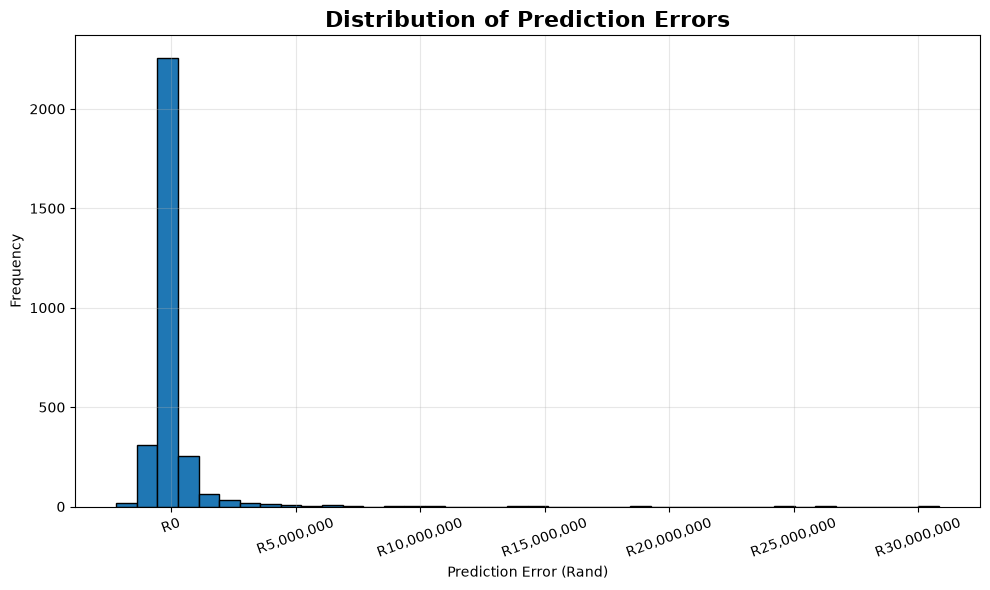

In [401]:
from matplotlib.ticker import FuncFormatter

errors = y_test - rf.predict(X_test)

plt.figure(figsize=(10,6))

plt.hist(
    errors,
    bins=40,
    edgecolor="black"
)

plt.title(
    "Distribution of Prediction Errors",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Prediction Error (Rand)")
plt.ylabel("Frequency")

# Format x-axis with commas instead of scientific notation
plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'R{x:,.0f}')
)

plt.xticks(rotation=20)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

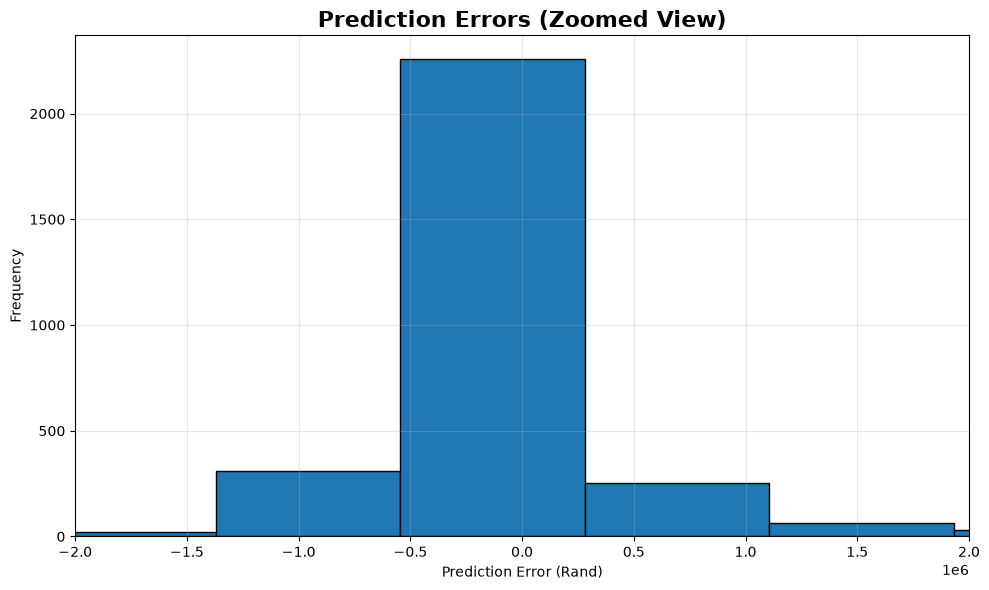

In [402]:
plt.figure(figsize=(10,6))

plt.hist(errors, bins=40, edgecolor="black")

plt.xlim(-2_000_000, 2_000_000)

plt.title("Prediction Errors (Zoomed View)", fontsize=16, weight="bold")
plt.xlabel("Prediction Error (Rand)")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation

The prediction error distribution is centered close to zero, indicating that the Random Forest model produces largely unbiased predictions across the test dataset.

The prediction errors are approximately centered around zero, indicating that the model does not consistently overestimate or underestimate vehicle prices. Most errors fall within a relatively narrow range, while a small number of larger errors occur for luxury and high-value vehicles. This pattern suggests that the Random Forest model generalizes well across the majority of vehicle listings while facing greater uncertainty for rare market segments.

Overall, the error distribution suggests that the model generalizes well to unseen data and does not exhibit systematic overestimation or underestimation of vehicle prices.

# Executive Summary

This notebook focused on improving the performance and interpretability of the DriveValue AI pricing model.

Hyperparameter optimization was performed to investigate whether the baseline Random Forest model could achieve higher predictive accuracy. Although multiple parameter combinations were evaluated using Randomized Search Cross Validation, the optimized model did not outperform the original Random Forest model on the unseen test dataset.

Explainable AI (SHAP) techniques were then applied to understand how individual vehicle characteristics influence predicted asking prices. Feature importance analysis revealed that vehicle age, brand, and specific vehicle models contribute most significantly to price predictions.

Finally, prediction error analysis demonstrated that the model generalizes well across unseen data, with most prediction errors centered around zero and only a small number of large errors occurring for high-value vehicles.

Overall, the results confirm that the original Random Forest model provides the best balance between predictive accuracy, interpretability, and business applicability.

# Key Findings

The following insights were obtained from the optimization and explainability process:

- The original Random Forest model remained the highest-performing model after hyperparameter tuning.
- Vehicle age was identified as one of the strongest predictors of asking price.
- Vehicle brand and model significantly influence price predictions.
- SHAP analysis improved model transparency by explaining individual feature contributions.
- Prediction errors were concentrated around zero, indicating reliable performance across most vehicle listings.
- The model demonstrated good generalization with no significant evidence of overfitting.

# Business Recommendations

Based on the model optimization and explainability results, the following recommendations are proposed:

### 1. Support Fair Vehicle Pricing

DriveValue AI can assist dealerships and online marketplaces by generating objective price estimates based on historical vehicle characteristics.

### 2. Increase Customer Trust

Explainable AI enables sellers and buyers to understand why a vehicle receives a particular price estimate, improving transparency during negotiations.

### 3. Improve Pricing Consistency

Automated pricing reduces human bias and promotes consistent pricing across similar vehicle listings.

### 4. Monitor High-Value Vehicles

Luxury and premium vehicles exhibit greater prediction errors. Future improvements could include collecting additional features such as service history, accident history, vehicle condition, and optional extras to improve prediction accuracy for these vehicles.

### 5. Continuous Model Improvement

As new vehicle listings become available, the model should be periodically retrained to maintain predictive performance under changing market conditions.

# Future Work

Several opportunities exist to further improve DriveValue AI:

- Collect additional vehicle characteristics such as service records, accident history, mileage verification, and vehicle condition.
- Investigate advanced ensemble methods such as XGBoost, LightGBM, and CatBoost.
- Develop a real-time web application for instant vehicle price estimation.
- Integrate live market data from online vehicle marketplaces.
- Expand Explainable AI by generating individualized explanations for every vehicle prediction.
- Investigate feature selection techniques to reduce dimensionality introduced by one-hot encoding while maintaining predictive performance.

# Conclusion

This notebook successfully enhanced the transparency of the DriveValue AI pricing model through hyperparameter optimization, Explainable AI, and prediction error analysis.

Although hyperparameter optimization did not improve predictive performance, it confirmed that the baseline Random Forest model remains the most suitable model for deployment.

Explainable AI demonstrated which vehicle characteristics most strongly influence price predictions, while error analysis confirmed that the model generalizes effectively to unseen data.

These findings strengthen the reliability, interpretability, and business value of DriveValue AI as a practical decision-support tool for used vehicle pricing.

## YOU HAVE COME TO THE END OF DRIVEVALUE AI.... THANK YOU !
### Author : Jaqualine Makgolana